# v1

Using device: cpu
Epoch     1 | Total: 2.004153e+01 | Phys: 1.418720e-01 | IC: 1.989966e+00
Epoch   500 | Total: 1.691306e-02 | Phys: 1.679453e-02 | IC: 1.185331e-05
Epoch  1000 | Total: 7.288142e-03 | Phys: 7.158566e-03 | IC: 1.295764e-05
Epoch  1500 | Total: 5.077829e-03 | Phys: 4.557903e-03 | IC: 5.199252e-05
Epoch  2000 | Total: 4.391025e-03 | Phys: 3.902211e-03 | IC: 4.888140e-05
Epoch  2500 | Total: 4.265985e-03 | Phys: 4.140182e-03 | IC: 1.258027e-05
Epoch  3000 | Total: 3.081158e-03 | Phys: 2.847120e-03 | IC: 2.340374e-05
Epoch  3500 | Total: 2.767011e-03 | Phys: 2.544418e-03 | IC: 2.225937e-05
Epoch  4000 | Total: 2.553412e-03 | Phys: 2.362528e-03 | IC: 1.908844e-05
Epoch  4500 | Total: 2.192148e-03 | Phys: 1.823870e-03 | IC: 3.682782e-05
Epoch  5000 | Total: 6.556796e-03 | Phys: 2.206820e-03 | IC: 4.349975e-04

Error Summary:
xi=0.10 | L2 error=2.511701e-01 | Max error=5.262120e-01
xi=0.20 | L2 error=7.998177e-02 | Max error=1.876200e-01
xi=0.30 | L2 error=2.782410e-02 | Max 

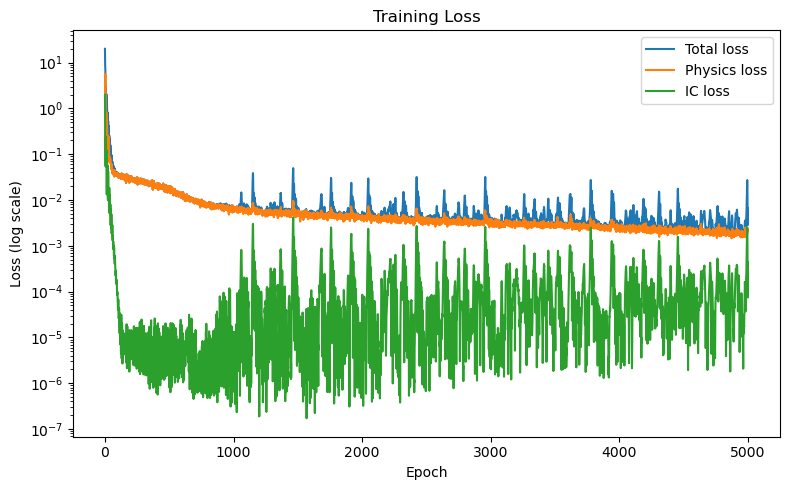

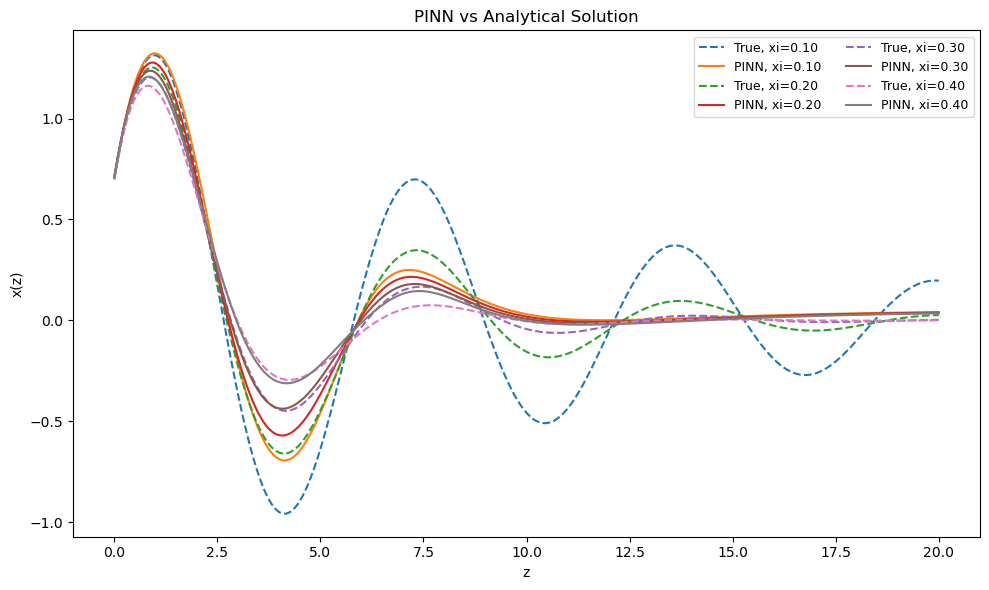

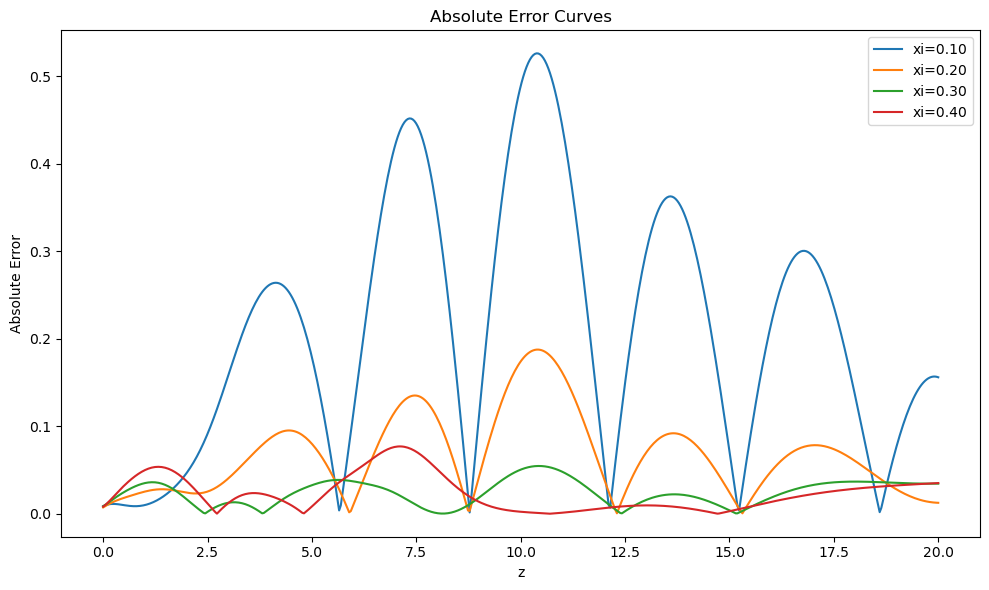

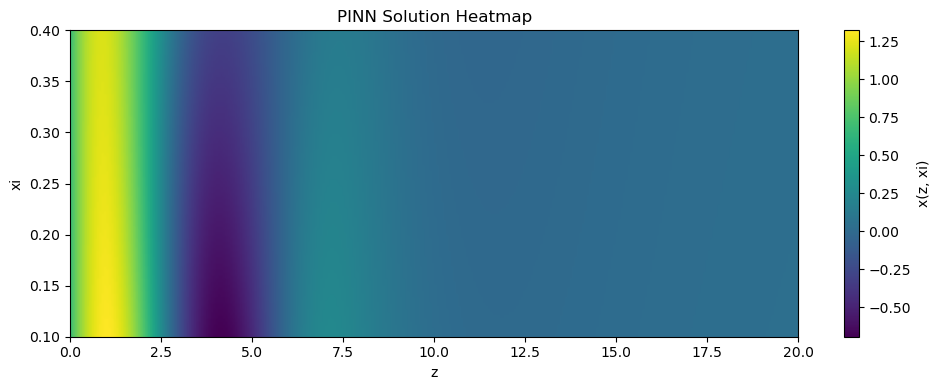


Model saved to pinnde_model.pt


In [15]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# =========================
# 0. Reproducibility
# =========================
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1. Problem setup
# =========================
X0 = 0.7
V0 = 1.2

XI_MIN = 0.1
XI_MAX = 0.4

Z_MIN = 0.0
Z_MAX = 20.0


# =========================
# 2. Analytical solution
#    x'' + 2*xi*x' + x = 0
#    underdamped for xi in [0.1, 0.4]
# =========================
def analytical_solution(z, xi, x0=X0, v0=V0):
    """
    z: numpy array or torch tensor
    xi: scalar or array
    """
    # Convert to numpy for convenience in plotting/evaluation
    z_np = np.asarray(z, dtype=np.float64)
    xi_np = np.asarray(xi, dtype=np.float64)

    wd = np.sqrt(1.0 - xi_np**2)
    c1 = x0
    c2 = (v0 + xi_np * x0) / wd

    return np.exp(-xi_np * z_np) * (
        c1 * np.cos(wd * z_np) + c2 * np.sin(wd * z_np)
    )


# =========================
# 3. PINN model
#    Input: [z, xi]
#    Output: x(z, xi)
# =========================
class PINN(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=128, num_hidden=4, out_dim=1):
        super().__init__()

        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]

        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, z, xi):
        # z, xi shape: (N, 1)
        inp = torch.cat([z, xi], dim=1)
        return self.net(inp)


# =========================
# 4. Sampling functions
# =========================
def sample_interior(n_samples):
    z = torch.rand(n_samples, 1, device=device) * (Z_MAX - Z_MIN) + Z_MIN
    xi = torch.rand(n_samples, 1, device=device) * (XI_MAX - XI_MIN) + XI_MIN

    z.requires_grad_(True)
    xi.requires_grad_(False)
    return z, xi


def sample_initial(n_samples):
    z0 = torch.zeros(n_samples, 1, device=device)
    xi = torch.rand(n_samples, 1, device=device) * (XI_MAX - XI_MIN) + XI_MIN

    z0.requires_grad_(True)
    xi.requires_grad_(False)
    return z0, xi


# =========================
# 5. Physics residual
#    x'' + 2*xi*x' + x = 0
# =========================
def compute_residual(model, z, xi):
    x = model(z, xi)

    dx_dz = torch.autograd.grad(
        x,
        z,
        grad_outputs=torch.ones_like(x),
        create_graph=True,
        retain_graph=True,
    )[0]

    d2x_dz2 = torch.autograd.grad(
        dx_dz,
        z,
        grad_outputs=torch.ones_like(dx_dz),
        create_graph=True,
        retain_graph=True,
    )[0]

    residual = d2x_dz2 + 2.0 * xi * dx_dz + x
    return x, dx_dz, d2x_dz2, residual


# =========================
# 6. Loss function
# =========================
def loss_fn(model, n_interior=1024, n_initial=256, lambda_ic=10.0):
    # Interior / physics points
    z_r, xi_r = sample_interior(n_interior)
    _, _, _, residual = compute_residual(model, z_r, xi_r)
    loss_phys = torch.mean(residual**2)

    # Initial condition points
    z0, xi0 = sample_initial(n_initial)
    x0_pred = model(z0, xi0)

    dx0_dz = torch.autograd.grad(
        x0_pred,
        z0,
        grad_outputs=torch.ones_like(x0_pred),
        create_graph=True,
        retain_graph=True,
    )[0]

    loss_x0 = torch.mean((x0_pred - X0) ** 2)
    loss_v0 = torch.mean((dx0_dz - V0) ** 2)
    loss_ic = loss_x0 + loss_v0

    loss = loss_phys + lambda_ic * loss_ic
    return loss, loss_phys.detach(), loss_ic.detach()


# =========================
# 7. Training
# =========================
def train_model(
    model,
    epochs_adam=5000,
    lr=1e-3,
    n_interior=1024,
    n_initial=256,
    lambda_ic=10.0,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "loss": [],
        "phys": [],
        "ic": [],
    }

    model.train()
    for epoch in range(1, epochs_adam + 1):
        optimizer.zero_grad()

        loss, loss_phys, loss_ic = loss_fn(
            model,
            n_interior=n_interior,
            n_initial=n_initial,
            lambda_ic=lambda_ic,
        )

        loss.backward()
        optimizer.step()

        history["loss"].append(loss.item())
        history["phys"].append(loss_phys.item())
        history["ic"].append(loss_ic.item())

        if epoch % 500 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:5d} | "
                f"Total: {loss.item():.6e} | "
                f"Phys: {loss_phys.item():.6e} | "
                f"IC: {loss_ic.item():.6e}"
            )

    return history


# =========================
# 8. Evaluation utilities
# =========================
@torch.no_grad()
def predict(model, z, xi):
    """
    z: numpy array shape (N,)
    xi: float
    """
    z_t = torch.tensor(z, dtype=torch.float32, device=device).reshape(-1, 1)
    xi_t = torch.full_like(z_t, fill_value=float(xi))
    pred = model(z_t, xi_t).cpu().numpy().reshape(-1)
    return pred


def evaluate_error(model, xi_values, num_points=500):
    results = []
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    for xi in xi_values:
        y_pred = predict(model, z, xi)
        y_true = analytical_solution(z, xi)

        abs_err = np.abs(y_pred - y_true)
        l2_err = np.sqrt(np.mean((y_pred - y_true) ** 2))
        max_err = np.max(abs_err)

        results.append(
            {
                "xi": xi,
                "l2_error": float(l2_err),
                "max_error": float(max_err),
            }
        )

    return results


# =========================
# 9. Plotting
# =========================
def plot_training_history(history):
    plt.figure(figsize=(8, 5))
    plt.semilogy(history["loss"], label="Total loss")
    plt.semilogy(history["phys"], label="Physics loss")
    plt.semilogy(history["ic"], label="IC loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (log scale)")
    plt.title("Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_predictions(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)

        plt.plot(z, y_true, linestyle="--", label=f"True, xi={xi:.2f}")
        plt.plot(z, y_pred, label=f"PINN, xi={xi:.2f}")

    plt.xlabel("z")
    plt.ylabel("x(z)")
    plt.title("PINN vs Analytical Solution")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_error_curves(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)
        abs_err = np.abs(y_pred - y_true)

        plt.plot(z, abs_err, label=f"xi={xi:.2f}")

    plt.xlabel("z")
    plt.ylabel("Absolute Error")
    plt.title("Absolute Error Curves")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_solution_heatmap(model, num_z=300, num_xi=100):
    z_grid = np.linspace(Z_MIN, Z_MAX, num_z)
    xi_grid = np.linspace(XI_MIN, XI_MAX, num_xi)

    Z, XI = np.meshgrid(z_grid, xi_grid)
    points_z = torch.tensor(Z.reshape(-1, 1), dtype=torch.float32, device=device)
    points_xi = torch.tensor(XI.reshape(-1, 1), dtype=torch.float32, device=device)

    with torch.no_grad():
        pred = model(points_z, points_xi).cpu().numpy().reshape(num_xi, num_z)

    plt.figure(figsize=(10, 4))
    plt.imshow(
        pred,
        aspect="auto",
        origin="lower",
        extent=[Z_MIN, Z_MAX, XI_MIN, XI_MAX],
    )
    plt.colorbar(label="x(z, xi)")
    plt.xlabel("z")
    plt.ylabel("xi")
    plt.title("PINN Solution Heatmap")
    plt.tight_layout()
    plt.show()


# =========================
# 10. Main
# =========================
def main():
    model = PINN(
        in_dim=2,
        hidden_dim=128,
        num_hidden=5,
        out_dim=1,
    ).to(device)

    history = train_model(
        model,
        epochs_adam=5000,
        lr=1e-3,
        n_interior=1024,
        n_initial=256,
        lambda_ic=10.0,
    )

    # Error summary
    xi_values = [0.1, 0.2, 0.3, 0.4]
    results = evaluate_error(model, xi_values)

    print("\nError Summary:")
    for r in results:
        print(
            f"xi={r['xi']:.2f} | "
            f"L2 error={r['l2_error']:.6e} | "
            f"Max error={r['max_error']:.6e}"
        )

    # Plots
    plot_training_history(history)
    plot_predictions(model, xi_values)
    plot_error_curves(model, xi_values)
    plot_solution_heatmap(model)

    # Save model
    torch.save(model.state_dict(), "pinnde_model.pt")
    print("\nModel saved to pinnde_model.pt")


if __name__ == "__main__":
    main()

# v2

Using device: cpu
[Adam] Epoch     1 | Physics loss: 4.917308e+02
[Adam] Epoch   500 | Physics loss: 2.879254e+10
[Adam] Epoch  1000 | Physics loss: 5.009483e+01
[Adam] Epoch  1500 | Physics loss: 5.006862e+01
[Adam] Epoch  2000 | Physics loss: 5.003273e+01
[Adam] Epoch  2500 | Physics loss: 4.998468e+01
[Adam] Epoch  3000 | Physics loss: 4.992179e+01
[Adam] Epoch  3500 | Physics loss: 4.983997e+01
[Adam] Epoch  4000 | Physics loss: 4.973444e+01


/var/folders/rs/tyy1wwls7vb4ddrkrn_jt_3c0000gn/T/ipykernel_58876/1176092408.py:302: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print(f"[L-BFGS] Final physics loss: {float(final_loss):.6e}")


[L-BFGS] Final physics loss: 5.505616e+01

Initial-condition check:
xi=0.10 | x(0) pred=nan | x'(0) pred=nan
xi=0.20 | x(0) pred=nan | x'(0) pred=nan
xi=0.30 | x(0) pred=nan | x'(0) pred=nan
xi=0.40 | x(0) pred=nan | x'(0) pred=nan

Error Summary:
xi=0.10 | L2 error=nan | Max error=nan
xi=0.20 | L2 error=nan | Max error=nan
xi=0.30 | L2 error=nan | Max error=nan
xi=0.40 | L2 error=nan | Max error=nan


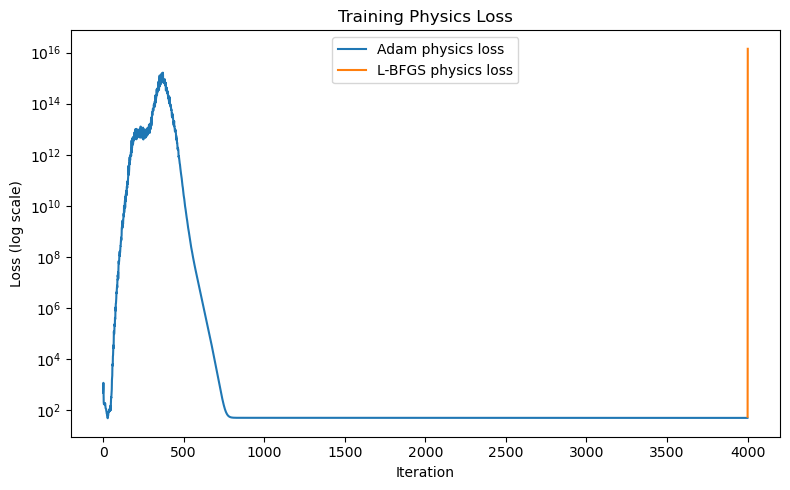

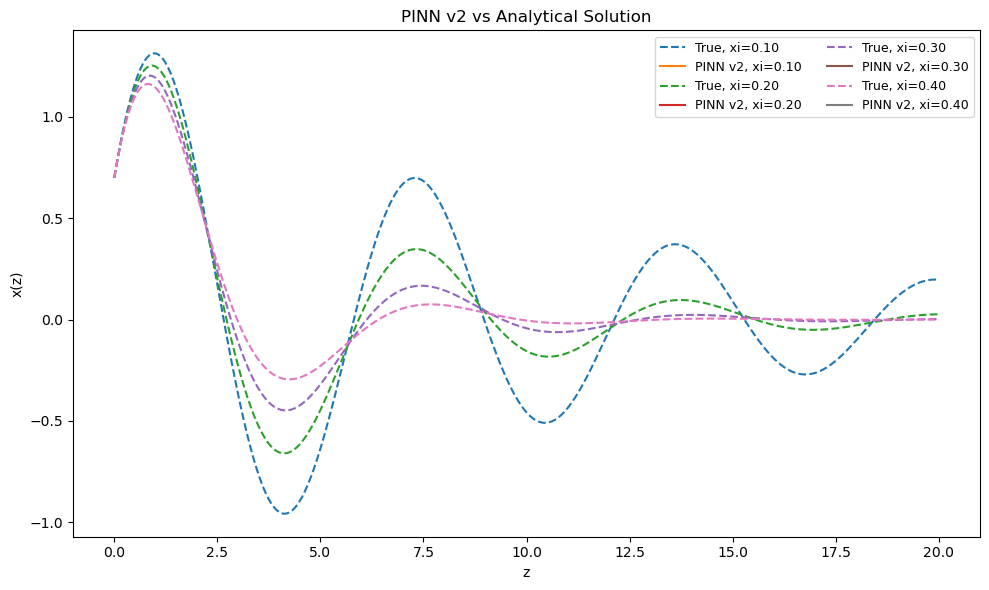

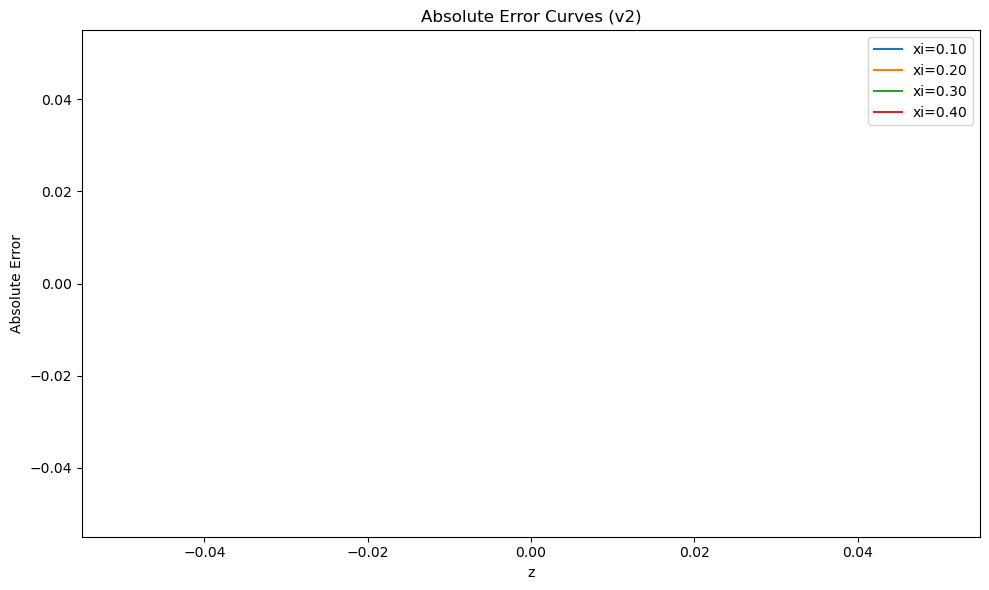

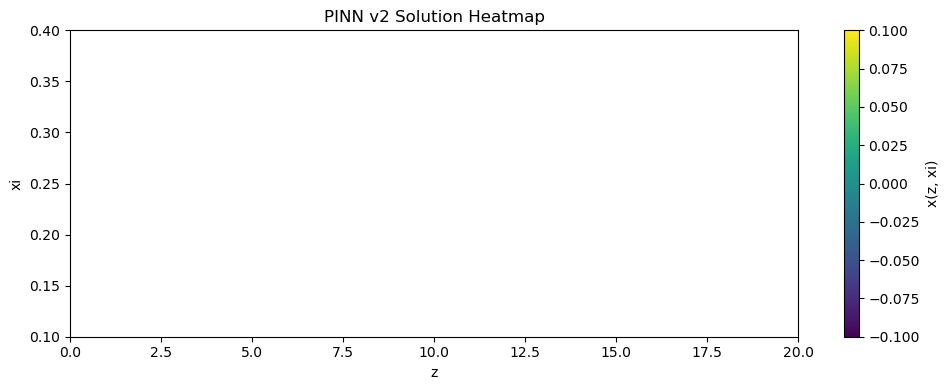


Model saved to pinnde_v2_model.pt


In [16]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# =========================
# 0. Reproducibility
# =========================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1. Problem setup
# =========================
X0 = 0.7
V0 = 1.2

XI_MIN = 0.1
XI_MAX = 0.4

Z_MIN = 0.0
Z_MAX = 20.0


# =========================
# 2. Analytical solution
# =========================
def analytical_solution(z, xi, x0=X0, v0=V0):
    z_np = np.asarray(z, dtype=np.float64)
    xi_np = np.asarray(xi, dtype=np.float64)

    wd = np.sqrt(1.0 - xi_np**2)
    c1 = x0
    c2 = (v0 + xi_np * x0) / wd

    return np.exp(-xi_np * z_np) * (
        c1 * np.cos(wd * z_np) + c2 * np.sin(wd * z_np)
    )


# =========================
# 3. Normalization helpers
#    map to [-1, 1]
# =========================
def normalize_z(z):
    return 2.0 * (z - Z_MIN) / (Z_MAX - Z_MIN) - 1.0


def normalize_xi(xi):
    return 2.0 * (xi - XI_MIN) / (XI_MAX - XI_MIN) - 1.0


# =========================
# 4. Network blocks
# =========================
class SineLayer(nn.Module):
    def __init__(self, in_dim, out_dim, is_first=False, omega_0=30.0):
        super().__init__()
        self.in_dim = in_dim
        self.linear = nn.Linear(in_dim, out_dim)
        self.is_first = is_first
        self.omega_0 = omega_0
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_dim, 1 / self.in_dim)
            else:
                bound = math.sqrt(6 / self.in_dim) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.zero_()

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


class MLP(nn.Module):
    def __init__(
        self,
        in_dim=2,
        hidden_dim=128,
        num_hidden=4,
        out_dim=1,
        activation="tanh",
    ):
        super().__init__()
        self.activation = activation.lower()

        layers = []

        if self.activation == "tanh":
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.Tanh())
            for _ in range(num_hidden - 1):
                layers.append(nn.Linear(hidden_dim, hidden_dim))
                layers.append(nn.Tanh())
            layers.append(nn.Linear(hidden_dim, out_dim))
            self.net = nn.Sequential(*layers)
            self._init_tanh()

        elif self.activation == "sine":
            layers.append(SineLayer(in_dim, hidden_dim, is_first=True, omega_0=30.0))
            for _ in range(num_hidden - 1):
                layers.append(SineLayer(hidden_dim, hidden_dim, is_first=False, omega_0=30.0))
            final = nn.Linear(hidden_dim, out_dim)
            with torch.no_grad():
                bound = math.sqrt(6 / hidden_dim) / 30.0
                final.weight.uniform_(-bound, bound)
                final.bias.zero_()
            layers.append(final)
            self.net = nn.Sequential(*layers)

        else:
            raise ValueError("activation must be 'tanh' or 'sine'")

    def _init_tanh(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# =========================
# 5. Trial-solution PINN
#    hard enforce:
#    x(0)=X0, x'(0)=V0
# =========================
class PINNTrial(nn.Module):
    def __init__(
        self,
        hidden_dim=128,
        num_hidden=4,
        activation="tanh",
    ):
        super().__init__()
        self.core = MLP(
            in_dim=2,
            hidden_dim=hidden_dim,
            num_hidden=num_hidden,
            out_dim=1,
            activation=activation,
        )

    def forward(self, z, xi):
        """
        z, xi: shape (N,1), original coordinates
        """
        z_norm = normalize_z(z)
        xi_norm = normalize_xi(xi)

        inp = torch.cat([z_norm, xi_norm], dim=1)
        n_out = self.core(inp)

        # Trial solution:
        # x_hat = x0 + v0*z + z^2 * N_theta(z, xi)
        x_hat = X0 + V0 * z + (z ** 2) * n_out
        return x_hat


# =========================
# 6. Sampling
# =========================
def sample_interior_uniform(n_samples):
    z = torch.rand(n_samples, 1, device=device) * (Z_MAX - Z_MIN) + Z_MIN
    xi = torch.rand(n_samples, 1, device=device) * (XI_MAX - XI_MIN) + XI_MIN
    z.requires_grad_(True)
    return z, xi


def sample_interior_sobol(n_samples):
    engine = torch.quasirandom.SobolEngine(dimension=2, scramble=True, seed=SEED)
    pts = engine.draw(n_samples).to(device)

    z = Z_MIN + (Z_MAX - Z_MIN) * pts[:, 0:1]
    xi = XI_MIN + (XI_MAX - XI_MIN) * pts[:, 1:2]
    z.requires_grad_(True)
    return z, xi


def sample_interior(n_samples, method="sobol"):
    if method == "sobol":
        return sample_interior_sobol(n_samples)
    elif method == "uniform":
        return sample_interior_uniform(n_samples)
    else:
        raise ValueError("method must be 'sobol' or 'uniform'")


# =========================
# 7. Residual
# =========================
def compute_residual(model, z, xi):
    x = model(z, xi)

    dx_dz = torch.autograd.grad(
        x,
        z,
        grad_outputs=torch.ones_like(x),
        create_graph=True,
        retain_graph=True,
    )[0]

    d2x_dz2 = torch.autograd.grad(
        dx_dz,
        z,
        grad_outputs=torch.ones_like(dx_dz),
        create_graph=True,
        retain_graph=True,
    )[0]

    residual = d2x_dz2 + 2.0 * xi * dx_dz + x
    return x, dx_dz, d2x_dz2, residual


# =========================
# 8. Physics-only loss
#    since IC is hard enforced
# =========================
def physics_loss(model, n_interior=2048, sample_method="sobol"):
    z, xi = sample_interior(n_interior, method=sample_method)
    _, _, _, residual = compute_residual(model, z, xi)
    loss = torch.mean(residual ** 2)
    return loss


# =========================
# 9. Training
# =========================
def train_adam(
    model,
    epochs=5000,
    lr=1e-3,
    n_interior=2048,
    sample_method="sobol",
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": []}

    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        loss = physics_loss(
            model,
            n_interior=n_interior,
            sample_method=sample_method,
        )
        loss.backward()
        optimizer.step()

        history["loss"].append(loss.item())

        if epoch % 500 == 0 or epoch == 1:
            print(f"[Adam] Epoch {epoch:5d} | Physics loss: {loss.item():.6e}")

    return history


def train_lbfgs(
    model,
    max_iter=500,
    n_interior=4096,
    sample_method="sobol",
):
    model.train()

    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=max_iter,
        max_eval=max_iter,
        tolerance_grad=1e-9,
        tolerance_change=1e-12,
        history_size=100,
        line_search_fn="strong_wolfe",
    )

    history = {"loss": []}

    # 固定一批点给 L-BFGS，避免 closure 中样本不断变化
    z_fixed, xi_fixed = sample_interior(n_interior, method=sample_method)

    def closure():
        optimizer.zero_grad()
        _, _, _, residual = compute_residual(model, z_fixed, xi_fixed)
        loss = torch.mean(residual ** 2)
        loss.backward()
        history["loss"].append(loss.item())
        return loss

    final_loss = optimizer.step(closure)
    print(f"[L-BFGS] Final physics loss: {float(final_loss):.6e}")
    return history


# =========================
# 10. Evaluation
# =========================
@torch.no_grad()
def predict(model, z, xi):
    z_t = torch.tensor(z, dtype=torch.float32, device=device).reshape(-1, 1)
    xi_t = torch.full_like(z_t, fill_value=float(xi))
    pred = model(z_t, xi_t).cpu().numpy().reshape(-1)
    return pred


def evaluate_error(model, xi_values, num_points=500):
    results = []
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    for xi in xi_values:
        y_pred = predict(model, z, xi)
        y_true = analytical_solution(z, xi)

        abs_err = np.abs(y_pred - y_true)
        l2_err = np.sqrt(np.mean((y_pred - y_true) ** 2))
        max_err = np.max(abs_err)

        results.append(
            {
                "xi": xi,
                "l2_error": float(l2_err),
                "max_error": float(max_err),
            }
        )

    return results


def check_initial_conditions(model, xi_values):
    print("\nInitial-condition check:")
    for xi in xi_values:
        z0 = torch.tensor([[0.0]], dtype=torch.float32, device=device, requires_grad=True)
        xi_t = torch.tensor([[xi]], dtype=torch.float32, device=device)

        x0_pred = model(z0, xi_t)
        dx0 = torch.autograd.grad(
            x0_pred,
            z0,
            grad_outputs=torch.ones_like(x0_pred),
            create_graph=False,
            retain_graph=False,
        )[0]

        print(
            f"xi={xi:.2f} | "
            f"x(0) pred={x0_pred.item():.8f} | "
            f"x'(0) pred={dx0.item():.8f}"
        )


# =========================
# 11. Plotting
# =========================
def plot_loss(adam_hist, lbfgs_hist=None):
    plt.figure(figsize=(8, 5))
    plt.semilogy(adam_hist["loss"], label="Adam physics loss")
    if lbfgs_hist is not None and len(lbfgs_hist["loss"]) > 0:
        x_offset = len(adam_hist["loss"])
        x_vals = np.arange(x_offset, x_offset + len(lbfgs_hist["loss"]))
        plt.semilogy(x_vals, lbfgs_hist["loss"], label="L-BFGS physics loss")

    plt.xlabel("Iteration")
    plt.ylabel("Loss (log scale)")
    plt.title("Training Physics Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_predictions(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)

        plt.plot(z, y_true, linestyle="--", label=f"True, xi={xi:.2f}")
        plt.plot(z, y_pred, label=f"PINN v2, xi={xi:.2f}")

    plt.xlabel("z")
    plt.ylabel("x(z)")
    plt.title("PINN v2 vs Analytical Solution")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_error_curves(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)
        abs_err = np.abs(y_pred - y_true)
        plt.plot(z, abs_err, label=f"xi={xi:.2f}")

    plt.xlabel("z")
    plt.ylabel("Absolute Error")
    plt.title("Absolute Error Curves (v2)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_solution_heatmap(model, num_z=300, num_xi=100):
    z_grid = np.linspace(Z_MIN, Z_MAX, num_z)
    xi_grid = np.linspace(XI_MIN, XI_MAX, num_xi)

    Z, XI = np.meshgrid(z_grid, xi_grid)
    z_t = torch.tensor(Z.reshape(-1, 1), dtype=torch.float32, device=device)
    xi_t = torch.tensor(XI.reshape(-1, 1), dtype=torch.float32, device=device)

    with torch.no_grad():
        pred = model(z_t, xi_t).cpu().numpy().reshape(num_xi, num_z)

    plt.figure(figsize=(10, 4))
    plt.imshow(
        pred,
        aspect="auto",
        origin="lower",
        extent=[Z_MIN, Z_MAX, XI_MIN, XI_MAX],
    )
    plt.colorbar(label="x(z, xi)")
    plt.xlabel("z")
    plt.ylabel("xi")
    plt.title("PINN v2 Solution Heatmap")
    plt.tight_layout()
    plt.show()


# =========================
# 12. Main
# =========================
def main():
    model = PINNTrial(
        hidden_dim=128,
        num_hidden=4,
        activation="sine",   # 可改成 "tanh"
    ).to(device)

    # Phase 1: Adam
    adam_hist = train_adam(
        model,
        epochs=4000,
        lr=1e-3,
        n_interior=2048,
        sample_method="sobol",
    )

    # Phase 2: L-BFGS
    lbfgs_hist = train_lbfgs(
        model,
        max_iter=500,
        n_interior=4096,
        sample_method="sobol",
    )

    xi_values = [0.1, 0.2, 0.3, 0.4]

    check_initial_conditions(model, xi_values)

    results = evaluate_error(model, xi_values)

    print("\nError Summary:")
    for r in results:
        print(
            f"xi={r['xi']:.2f} | "
            f"L2 error={r['l2_error']:.6e} | "
            f"Max error={r['max_error']:.6e}"
        )

    plot_loss(adam_hist, lbfgs_hist)
    plot_predictions(model, xi_values)
    plot_error_curves(model, xi_values)
    plot_solution_heatmap(model)

    torch.save(model.state_dict(), "pinnde_v2_model.pt")
    print("\nModel saved to pinnde_v2_model.pt")


if __name__ == "__main__":
    main()

# v3

Using device: cpu
Epoch     1 | Physics loss: 2.233699e+02
Epoch   500 | Physics loss: 1.735766e+01
Epoch  1000 | Physics loss: 9.839844e+00
Epoch  1500 | Physics loss: 2.620966e+00
Epoch  2000 | Physics loss: 1.651457e+00
Epoch  2500 | Physics loss: 1.139377e+00
Epoch  3000 | Physics loss: 8.633250e-01
Epoch  3500 | Physics loss: 6.959857e-01
Epoch  4000 | Physics loss: 5.930186e-01
Epoch  4500 | Physics loss: 5.674103e-01
Epoch  5000 | Physics loss: 3.909091e-01
Epoch  5500 | Physics loss: 3.635565e-01
Epoch  6000 | Physics loss: 3.069125e-01
Epoch  6500 | Physics loss: 2.639284e-01
Epoch  7000 | Physics loss: 2.296724e-01
Epoch  7500 | Physics loss: 1.843845e-01
Epoch  8000 | Physics loss: 1.867498e-01

Initial-condition check:
xi=0.10 | x(0)=0.69999999 | x'(0)=1.20000005
xi=0.20 | x(0)=0.69999999 | x'(0)=1.20000005
xi=0.30 | x(0)=0.69999999 | x'(0)=1.20000005
xi=0.40 | x(0)=0.69999999 | x'(0)=1.20000005

Error Summary:
xi=0.10 | L2 error=7.028517e-01 | Max error=1.792232e+00
xi=0.2

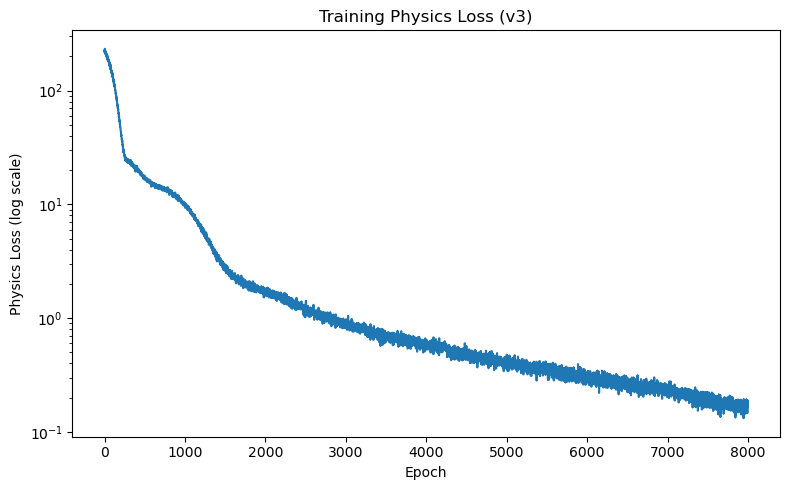

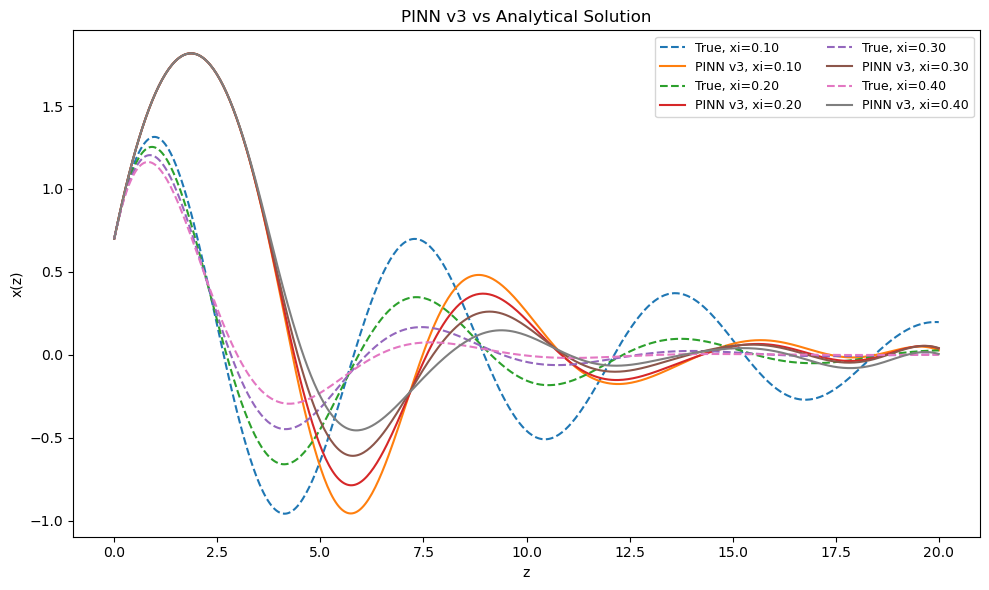

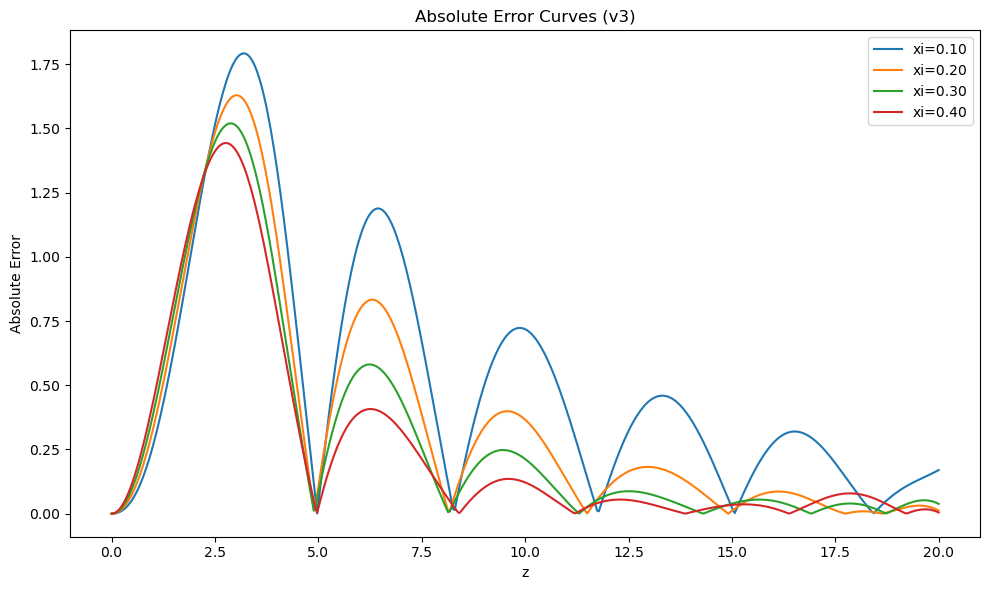


Model saved to pinnde_v3_model.pt


In [17]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# =========================
# 0. Reproducibility
# =========================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1. Problem setup
# =========================
X0 = 0.7
V0 = 1.2

XI_MIN = 0.1
XI_MAX = 0.4

Z_MIN = 0.0
Z_MAX = 20.0


# =========================
# 2. Analytical solution
# =========================
def analytical_solution(z, xi, x0=X0, v0=V0):
    z_np = np.asarray(z, dtype=np.float64)
    xi_np = np.asarray(xi, dtype=np.float64)

    wd = np.sqrt(1.0 - xi_np**2)
    c1 = x0
    c2 = (v0 + xi_np * x0) / wd

    return np.exp(-xi_np * z_np) * (
        c1 * np.cos(wd * z_np) + c2 * np.sin(wd * z_np)
    )


# =========================
# 3. Normalization
# =========================
def normalize_z(z):
    return z / Z_MAX   # [0,20] -> [0,1]


def normalize_xi(xi):
    return 2.0 * (xi - XI_MIN) / (XI_MAX - XI_MIN) - 1.0  # -> [-1,1]


# =========================
# 4. Stable MLP
# =========================
class StablePINN(nn.Module):
    def __init__(self, hidden_dim=64, num_hidden=3):
        super().__init__()

        layers = []
        in_dim = 2
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(num_hidden - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, z, xi):
        z_norm = normalize_z(z)
        xi_norm = normalize_xi(xi)
        inp = torch.cat([z_norm, xi_norm], dim=1)

        n_out = self.net(inp)

        # 更稳的 trial solution：
        # 用小系数抑制修正项爆炸
        x_hat = X0 + V0 * z + 0.01 * (z ** 2) * n_out
        return x_hat


# =========================
# 5. Sampling
# =========================
def sample_interior(n_samples):
    z = torch.rand(n_samples, 1, device=device) * (Z_MAX - Z_MIN) + Z_MIN
    xi = torch.rand(n_samples, 1, device=device) * (XI_MAX - XI_MIN) + XI_MIN
    z.requires_grad_(True)
    return z, xi


# =========================
# 6. Residual
# =========================
def compute_residual(model, z, xi):
    x = model(z, xi)

    dx_dz = torch.autograd.grad(
        x, z,
        grad_outputs=torch.ones_like(x),
        create_graph=True,
        retain_graph=True
    )[0]

    d2x_dz2 = torch.autograd.grad(
        dx_dz, z,
        grad_outputs=torch.ones_like(dx_dz),
        create_graph=True,
        retain_graph=True
    )[0]

    residual = d2x_dz2 + 2.0 * xi * dx_dz + x
    return x, dx_dz, d2x_dz2, residual


# =========================
# 7. Loss
# =========================
def physics_loss(model, n_interior=1024):
    z, xi = sample_interior(n_interior)
    _, _, _, residual = compute_residual(model, z, xi)
    return torch.mean(residual ** 2)


# =========================
# 8. Train
# =========================
def train_model(model, epochs=8000, lr=1e-4, n_interior=1024):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        loss = physics_loss(model, n_interior=n_interior)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Numerical issue at epoch {epoch}, stopping.")
            break

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        history.append(loss.item())

        if epoch % 500 == 0 or epoch == 1:
            print(f"Epoch {epoch:5d} | Physics loss: {loss.item():.6e}")

    return history


# =========================
# 9. Evaluation
# =========================
@torch.no_grad()
def predict(model, z, xi):
    z_t = torch.tensor(z, dtype=torch.float32, device=device).reshape(-1, 1)
    xi_t = torch.full_like(z_t, fill_value=float(xi))
    pred = model(z_t, xi_t).cpu().numpy().reshape(-1)
    return pred


def evaluate_error(model, xi_values, num_points=500):
    results = []
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    for xi in xi_values:
        y_pred = predict(model, z, xi)
        y_true = analytical_solution(z, xi)

        abs_err = np.abs(y_pred - y_true)
        l2_err = np.sqrt(np.mean((y_pred - y_true) ** 2))
        max_err = np.max(abs_err)

        results.append((xi, l2_err, max_err))

    return results


def check_initial_conditions(model, xi_values):
    print("\nInitial-condition check:")
    for xi in xi_values:
        z0 = torch.tensor([[0.0]], dtype=torch.float32, device=device, requires_grad=True)
        xi_t = torch.tensor([[xi]], dtype=torch.float32, device=device)

        x0_pred = model(z0, xi_t)
        dx0 = torch.autograd.grad(
            x0_pred, z0,
            grad_outputs=torch.ones_like(x0_pred),
            create_graph=False
        )[0]

        print(
            f"xi={xi:.2f} | x(0)={x0_pred.item():.8f} | x'(0)={dx0.item():.8f}"
        )


# =========================
# 10. Plot
# =========================
def plot_loss(history):
    plt.figure(figsize=(8, 5))
    plt.semilogy(history)
    plt.xlabel("Epoch")
    plt.ylabel("Physics Loss (log scale)")
    plt.title("Training Physics Loss (v3)")
    plt.tight_layout()
    plt.show()


def plot_predictions(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)

        plt.plot(z, y_true, '--', label=f"True, xi={xi:.2f}")
        plt.plot(z, y_pred, label=f"PINN v3, xi={xi:.2f}")

    plt.xlabel("z")
    plt.ylabel("x(z)")
    plt.title("PINN v3 vs Analytical Solution")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_error_curves(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)
        abs_err = np.abs(y_pred - y_true)
        plt.plot(z, abs_err, label=f"xi={xi:.2f}")

    plt.xlabel("z")
    plt.ylabel("Absolute Error")
    plt.title("Absolute Error Curves (v3)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# 11. Main
# =========================
def main():
    model = StablePINN(hidden_dim=64, num_hidden=3).to(device)

    history = train_model(
        model,
        epochs=8000,
        lr=1e-4,
        n_interior=1024
    )

    xi_values = [0.1, 0.2, 0.3, 0.4]

    check_initial_conditions(model, xi_values)

    results = evaluate_error(model, xi_values)
    print("\nError Summary:")
    for xi, l2_err, max_err in results:
        print(f"xi={xi:.2f} | L2 error={l2_err:.6e} | Max error={max_err:.6e}")

    plot_loss(history)
    plot_predictions(model, xi_values)
    plot_error_curves(model, xi_values)

    torch.save(model.state_dict(), "pinnde_v3_model.pt")
    print("\nModel saved to pinnde_v3_model.pt")


if __name__ == "__main__":
    main()

# v4

Using device: cpu

=== Stage 1: train on z in [0, 5.0] for 2000 epochs ===
Global Epoch     1 | Total: 1.155211e+02 | Phys: 6.366486e-01 | IC: 3.829481e+00
Global Epoch   500 | Total: 1.099010e-02 | Phys: 1.412208e-03 | IC: 3.192632e-04
Global Epoch  1000 | Total: 1.464491e-02 | Phys: 4.289259e-04 | IC: 4.738662e-04
Global Epoch  1500 | Total: 9.143931e-03 | Phys: 3.666160e-04 | IC: 2.925772e-04
Global Epoch  2000 | Total: 8.311585e-03 | Phys: 2.526155e-04 | IC: 2.686323e-04

=== Stage 2: train on z in [0, 10.0] for 2000 epochs ===
Global Epoch  2001 | Total: 6.127451e-01 | Phys: 6.084385e-01 | IC: 2.153295e-04
Global Epoch  2500 | Total: 6.275692e-04 | Phys: 6.058330e-04 | IC: 1.086813e-06
Global Epoch  3000 | Total: 2.453977e-04 | Phys: 2.418871e-04 | IC: 1.755298e-07
Global Epoch  3500 | Total: 5.904051e-04 | Phys: 1.239838e-04 | IC: 2.332107e-05
Global Epoch  4000 | Total: 4.550260e-04 | Phys: 1.137672e-04 | IC: 1.706294e-05

=== Stage 3: train on z in [0, 15.0] for 2000 epochs ===

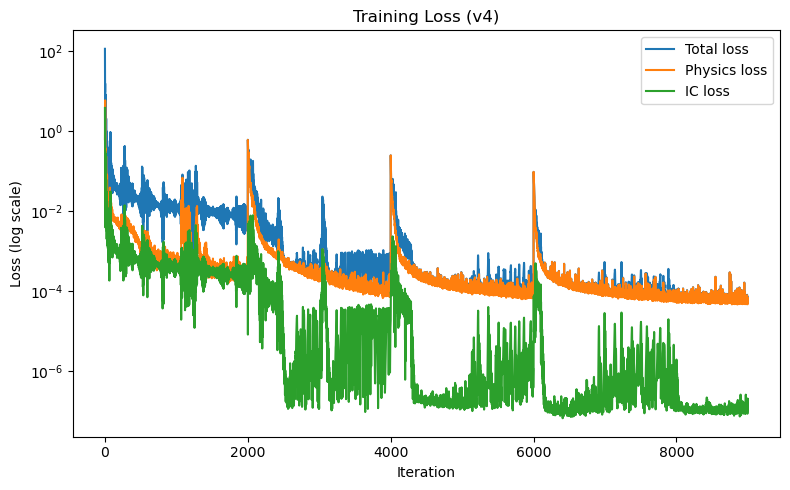

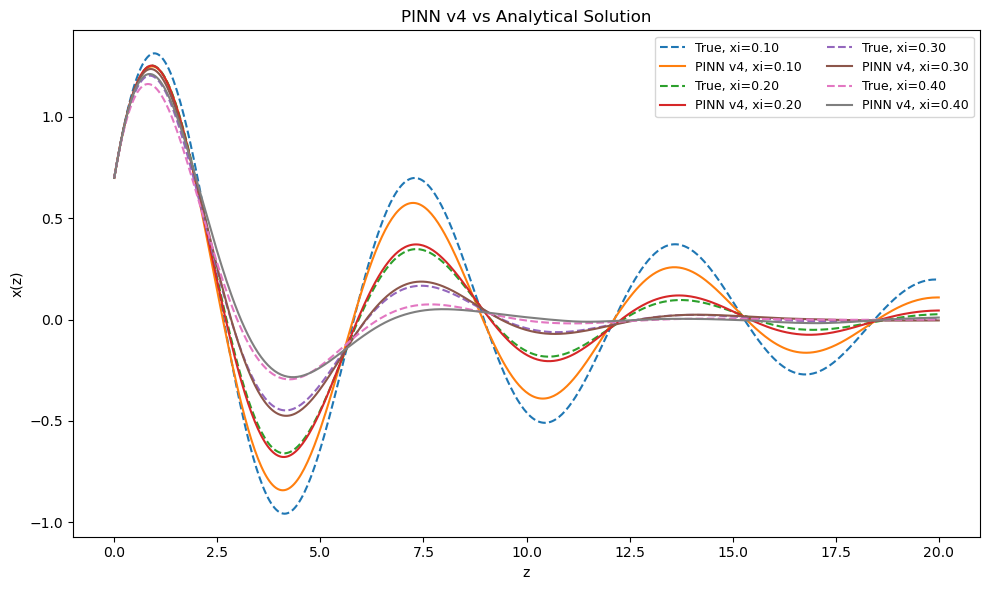

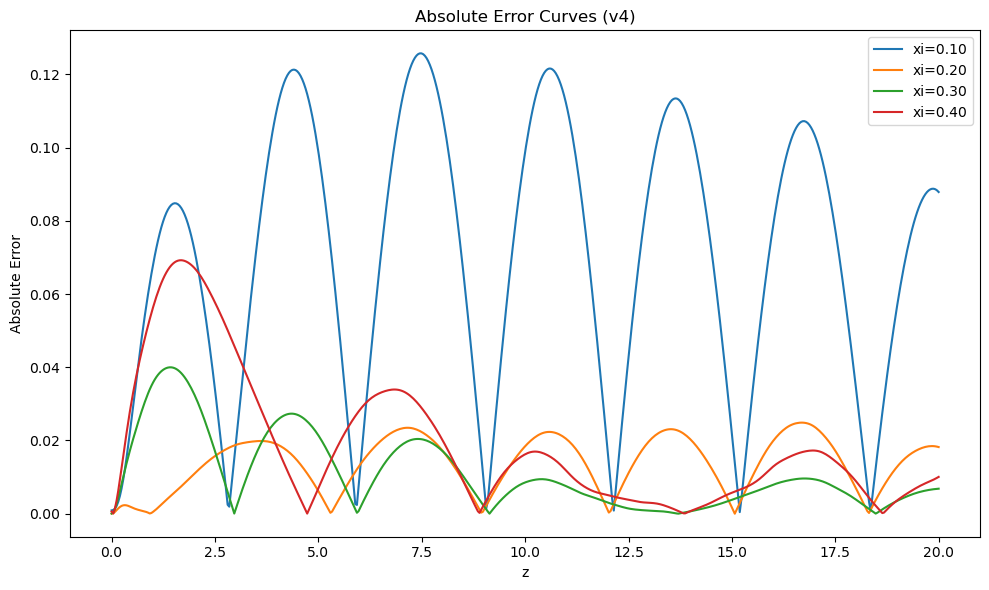

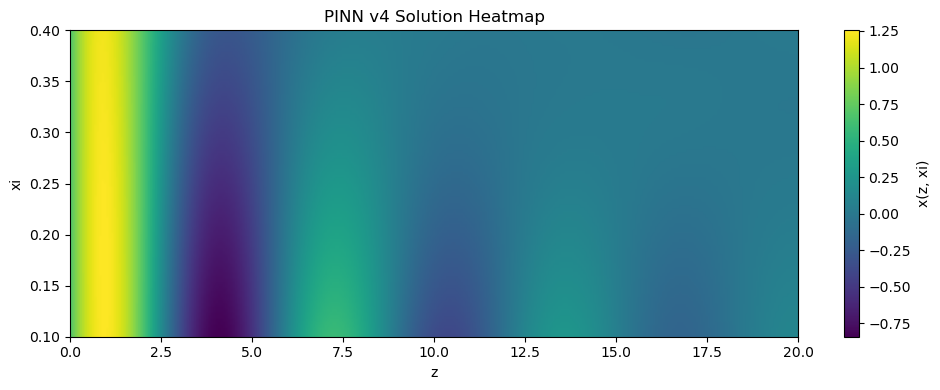


Model saved to pinnde_v4_model.pt


In [18]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# =========================
# 0. Reproducibility
# =========================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 1. Problem setup
# =========================
X0 = 0.7
V0 = 1.2

XI_MIN = 0.1
XI_MAX = 0.4

Z_MIN = 0.0
Z_MAX = 20.0


# =========================
# 2. Analytical solution
# =========================
def analytical_solution(z, xi, x0=X0, v0=V0):
    z_np = np.asarray(z, dtype=np.float64)
    xi_np = np.asarray(xi, dtype=np.float64)

    wd = np.sqrt(1.0 - xi_np**2)
    c1 = x0
    c2 = (v0 + xi_np * x0) / wd

    return np.exp(-xi_np * z_np) * (
        c1 * np.cos(wd * z_np) + c2 * np.sin(wd * z_np)
    )


# =========================
# 3. Normalization
# =========================
def normalize_z(z):
    # map [0, z_max] -> [-1, 1]
    return 2.0 * z / Z_MAX - 1.0


def normalize_xi(xi):
    return 2.0 * (xi - XI_MIN) / (XI_MAX - XI_MIN) - 1.0


# =========================
# 4. Fourier feature encoding
# =========================
class FourierFeatures(nn.Module):
    def __init__(self, num_bands=4):
        super().__init__()
        self.num_bands = num_bands
        self.freqs = 2.0 ** torch.arange(num_bands, dtype=torch.float32)

    def forward(self, z_norm, xi_norm):
        """
        z_norm, xi_norm: (N,1)
        output:
            [z, xi, sin(2^k pi z), cos(2^k pi z), z*xi]
        """
        freqs = self.freqs.to(z_norm.device).view(1, -1)  # (1, B)

        z_proj = math.pi * z_norm * freqs  # (N, B)
        sin_z = torch.sin(z_proj)
        cos_z = torch.cos(z_proj)

        out = torch.cat(
            [
                z_norm,
                xi_norm,
                sin_z,
                cos_z,
                z_norm * xi_norm,
            ],
            dim=1,
        )
        return out


# =========================
# 5. PINN model
# =========================
class PINNv4(nn.Module):
    def __init__(self, hidden_dim=128, num_hidden=4, num_bands=4):
        super().__init__()

        self.encoder = FourierFeatures(num_bands=num_bands)
        in_dim = 2 + 2 * num_bands + 1  # z, xi, sin/cos, z*xi

        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(num_hidden - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, z, xi):
        z_norm = normalize_z(z)
        xi_norm = normalize_xi(xi)
        feat = self.encoder(z_norm, xi_norm)
        return self.net(feat)


# =========================
# 6. Sampling
# =========================
def sample_interior(n_samples, z_upper):
    """
    biased sampling:
    - more weight on larger z
    - more weight on smaller xi
    """
    # z: bias to later region
    u = torch.rand(n_samples, 1, device=device)
    z = z_upper * torch.sqrt(u)   # more samples near larger z

    # xi: bias to lower xi
    u2 = torch.rand(n_samples, 1, device=device)
    xi = XI_MIN + (XI_MAX - XI_MIN) * (u2 ** 1.5)

    z.requires_grad_(True)
    return z, xi


def sample_initial(n_samples):
    z0 = torch.zeros(n_samples, 1, device=device)
    xi = torch.rand(n_samples, 1, device=device) * (XI_MAX - XI_MIN) + XI_MIN
    z0.requires_grad_(True)
    return z0, xi


# =========================
# 7. Residual
# =========================
def compute_residual(model, z, xi):
    x = model(z, xi)

    dx_dz = torch.autograd.grad(
        x,
        z,
        grad_outputs=torch.ones_like(x),
        create_graph=True,
        retain_graph=True,
    )[0]

    d2x_dz2 = torch.autograd.grad(
        dx_dz,
        z,
        grad_outputs=torch.ones_like(dx_dz),
        create_graph=True,
        retain_graph=True,
    )[0]

    residual = d2x_dz2 + 2.0 * xi * dx_dz + x
    return x, dx_dz, d2x_dz2, residual


# =========================
# 8. Loss
# =========================
def loss_fn(model, n_interior=1024, n_initial=256, z_upper=20.0, lambda_ic=20.0):
    # physics loss
    z_r, xi_r = sample_interior(n_interior, z_upper=z_upper)
    _, _, _, residual = compute_residual(model, z_r, xi_r)
    loss_phys = torch.mean(residual ** 2)

    # initial conditions
    z0, xi0 = sample_initial(n_initial)
    x0_pred = model(z0, xi0)

    dx0_dz = torch.autograd.grad(
        x0_pred,
        z0,
        grad_outputs=torch.ones_like(x0_pred),
        create_graph=True,
        retain_graph=True,
    )[0]

    loss_x0 = torch.mean((x0_pred - X0) ** 2)
    loss_v0 = torch.mean((dx0_dz - V0) ** 2)
    loss_ic = loss_x0 + loss_v0

    loss = loss_phys + lambda_ic * loss_ic
    return loss, loss_phys.detach(), loss_ic.detach()


# =========================
# 9. Curriculum training
# =========================
def train_curriculum(model, curriculum_stages):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

    history = {"loss": [], "phys": [], "ic": []}

    model.train()

    global_epoch = 0
    for stage_id, stage in enumerate(curriculum_stages, start=1):
        z_upper = stage["z_upper"]
        epochs = stage["epochs"]
        lambda_ic = stage.get("lambda_ic", 20.0)
        n_interior = stage.get("n_interior", 1024)
        n_initial = stage.get("n_initial", 256)

        print(f"\n=== Stage {stage_id}: train on z in [0, {z_upper}] for {epochs} epochs ===")

        for epoch in range(1, epochs + 1):
            global_epoch += 1
            optimizer.zero_grad()

            loss, loss_phys, loss_ic = loss_fn(
                model,
                n_interior=n_interior,
                n_initial=n_initial,
                z_upper=z_upper,
                lambda_ic=lambda_ic,
            )

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Numerical issue at global epoch {global_epoch}, stopping.")
                return history

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            history["loss"].append(loss.item())
            history["phys"].append(loss_phys.item())
            history["ic"].append(loss_ic.item())

            if global_epoch % 500 == 0 or epoch == 1:
                print(
                    f"Global Epoch {global_epoch:5d} | "
                    f"Total: {loss.item():.6e} | "
                    f"Phys: {loss_phys.item():.6e} | "
                    f"IC: {loss_ic.item():.6e}"
                )

    return history


# =========================
# 10. Evaluation
# =========================
@torch.no_grad()
def predict(model, z, xi):
    z_t = torch.tensor(z, dtype=torch.float32, device=device).reshape(-1, 1)
    xi_t = torch.full_like(z_t, fill_value=float(xi))
    pred = model(z_t, xi_t).cpu().numpy().reshape(-1)
    return pred


def evaluate_error(model, xi_values, num_points=500):
    results = []
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    for xi in xi_values:
        y_pred = predict(model, z, xi)
        y_true = analytical_solution(z, xi)

        abs_err = np.abs(y_pred - y_true)
        l2_err = np.sqrt(np.mean((y_pred - y_true) ** 2))
        max_err = np.max(abs_err)

        results.append(
            {
                "xi": xi,
                "l2_error": float(l2_err),
                "max_error": float(max_err),
            }
        )

    return results


def check_initial_conditions(model, xi_values):
    print("\nInitial-condition check:")
    for xi in xi_values:
        z0 = torch.tensor([[0.0]], dtype=torch.float32, device=device, requires_grad=True)
        xi_t = torch.tensor([[xi]], dtype=torch.float32, device=device)

        x0_pred = model(z0, xi_t)
        dx0 = torch.autograd.grad(
            x0_pred,
            z0,
            grad_outputs=torch.ones_like(x0_pred),
            create_graph=False,
            retain_graph=False,
        )[0]

        print(
            f"xi={xi:.2f} | "
            f"x(0) pred={x0_pred.item():.8f} | "
            f"x'(0) pred={dx0.item():.8f}"
        )


# =========================
# 11. Plotting
# =========================
def plot_training_history(history):
    plt.figure(figsize=(8, 5))
    plt.semilogy(history["loss"], label="Total loss")
    plt.semilogy(history["phys"], label="Physics loss")
    plt.semilogy(history["ic"], label="IC loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss (log scale)")
    plt.title("Training Loss (v4)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_predictions(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)

        plt.plot(z, y_true, linestyle="--", label=f"True, xi={xi:.2f}")
        plt.plot(z, y_pred, label=f"PINN v4, xi={xi:.2f}")

    plt.xlabel("z")
    plt.ylabel("x(z)")
    plt.title("PINN v4 vs Analytical Solution")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_error_curves(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)
        abs_err = np.abs(y_pred - y_true)
        plt.plot(z, abs_err, label=f"xi={xi:.2f}")

    plt.xlabel("z")
    plt.ylabel("Absolute Error")
    plt.title("Absolute Error Curves (v4)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_solution_heatmap(model, num_z=300, num_xi=100):
    z_grid = np.linspace(Z_MIN, Z_MAX, num_z)
    xi_grid = np.linspace(XI_MIN, XI_MAX, num_xi)

    Z, XI = np.meshgrid(z_grid, xi_grid)
    z_t = torch.tensor(Z.reshape(-1, 1), dtype=torch.float32, device=device)
    xi_t = torch.tensor(XI.reshape(-1, 1), dtype=torch.float32, device=device)

    with torch.no_grad():
        pred = model(z_t, xi_t).cpu().numpy().reshape(num_xi, num_z)

    plt.figure(figsize=(10, 4))
    plt.imshow(
        pred,
        aspect="auto",
        origin="lower",
        extent=[Z_MIN, Z_MAX, XI_MIN, XI_MAX],
    )
    plt.colorbar(label="x(z, xi)")
    plt.xlabel("z")
    plt.ylabel("xi")
    plt.title("PINN v4 Solution Heatmap")
    plt.tight_layout()
    plt.show()


# =========================
# 12. Main
# =========================
def main():
    model = PINNv4(hidden_dim=128, num_hidden=4, num_bands=4).to(device)

    curriculum_stages = [
        {"z_upper": 5.0,  "epochs": 2000, "lambda_ic": 30.0, "n_interior": 1024, "n_initial": 256},
        {"z_upper": 10.0, "epochs": 2000, "lambda_ic": 20.0, "n_interior": 1024, "n_initial": 256},
        {"z_upper": 15.0, "epochs": 2000, "lambda_ic": 20.0, "n_interior": 1536, "n_initial": 256},
        {"z_upper": 20.0, "epochs": 3000, "lambda_ic": 15.0, "n_interior": 2048, "n_initial": 256},
    ]

    history = train_curriculum(model, curriculum_stages)

    xi_values = [0.1, 0.2, 0.3, 0.4]

    check_initial_conditions(model, xi_values)

    results = evaluate_error(model, xi_values)

    print("\nError Summary:")
    for r in results:
        print(
            f"xi={r['xi']:.2f} | "
            f"L2 error={r['l2_error']:.6e} | "
            f"Max error={r['max_error']:.6e}"
        )

    plot_training_history(history)
    plot_predictions(model, xi_values)
    plot_error_curves(model, xi_values)
    plot_solution_heatmap(model)

    torch.save(model.state_dict(), "pinnde_v4_model.pt")
    print("\nModel saved to pinnde_v4_model.pt")


if __name__ == "__main__":
    main()

# v5

Using device: cpu

=== Stage 1: train on z in [0, 5.0] for 2000 epochs ===
Global Epoch     1 | Total: 1.155211e+02 | Phys: 6.366486e-01 | IC: 3.829481e+00
Global Epoch   500 | Total: 1.099010e-02 | Phys: 1.412208e-03 | IC: 3.192632e-04
Global Epoch  1000 | Total: 1.464491e-02 | Phys: 4.289259e-04 | IC: 4.738662e-04
Global Epoch  1500 | Total: 9.143931e-03 | Phys: 3.666160e-04 | IC: 2.925772e-04
Global Epoch  2000 | Total: 8.311585e-03 | Phys: 2.526155e-04 | IC: 2.686323e-04

=== Stage 2: train on z in [0, 10.0] for 2000 epochs ===
Global Epoch  2001 | Total: 6.127451e-01 | Phys: 6.084385e-01 | IC: 2.153295e-04
Global Epoch  2500 | Total: 6.275692e-04 | Phys: 6.058330e-04 | IC: 1.086813e-06
Global Epoch  3000 | Total: 2.453977e-04 | Phys: 2.418871e-04 | IC: 1.755298e-07
Global Epoch  3500 | Total: 5.904051e-04 | Phys: 1.239838e-04 | IC: 2.332107e-05
Global Epoch  4000 | Total: 4.550260e-04 | Phys: 1.137672e-04 | IC: 1.706294e-05

=== Stage 3: train on z in [0, 15.0] for 2000 epochs ===

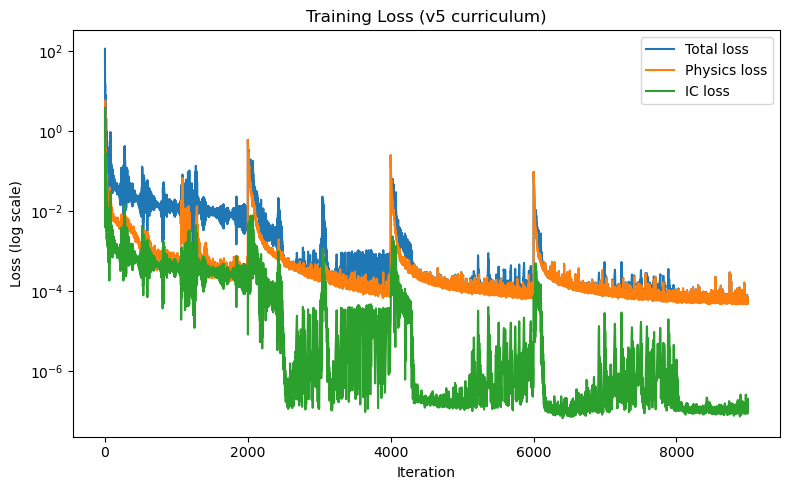


=== Adaptive fine-tuning ===
[Adaptive] Epoch     1 | Total: 4.172036e-02 | Phys: 4.171846e-02 | IC: 1.262764e-07
[Adaptive] Epoch   250 | Total: 3.949214e-04 | Phys: 2.685161e-04 | IC: 8.427016e-06
[Adaptive] Epoch   500 | Total: 3.421334e-04 | Phys: 1.874699e-04 | IC: 1.031090e-05
[Adaptive] Epoch   750 | Total: 7.923656e-04 | Phys: 1.641514e-04 | IC: 4.188095e-05
[Adaptive] Epoch  1000 | Total: 1.296880e-04 | Phys: 1.220485e-04 | IC: 5.092998e-07
[Adaptive] Epoch  1250 | Total: 1.443170e-04 | Phys: 1.189964e-04 | IC: 1.688038e-06
[Adaptive] Epoch  1500 | Total: 3.803528e-04 | Phys: 1.090807e-04 | IC: 1.808481e-05


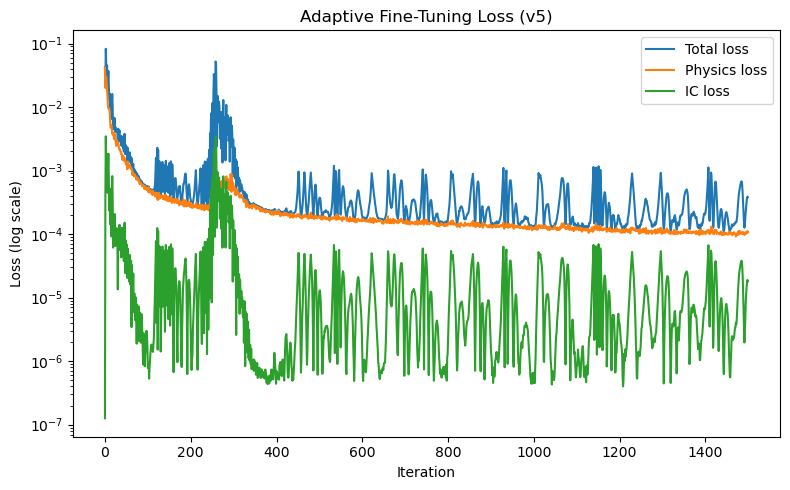


=== Safe L-BFGS polishing ===
[L-BFGS] Final loss: 3.171547e-04

Initial-condition check:
xi=0.10 | x(0) pred=0.69902790 | x'(0) pred=1.19933605
xi=0.20 | x(0) pred=0.70015252 | x'(0) pred=1.20007563
xi=0.30 | x(0) pred=0.69989926 | x'(0) pred=1.19997573
xi=0.40 | x(0) pred=0.69936866 | x'(0) pred=1.19976723

Error Summary:
xi=0.10 | L2 error=6.624002e-02 | Max error=1.052087e-01
xi=0.20 | L2 error=1.453632e-02 | Max error=3.127728e-02
xi=0.30 | L2 error=7.093555e-03 | Max error=1.346110e-02
xi=0.40 | L2 error=9.317356e-03 | Max error=1.914811e-02


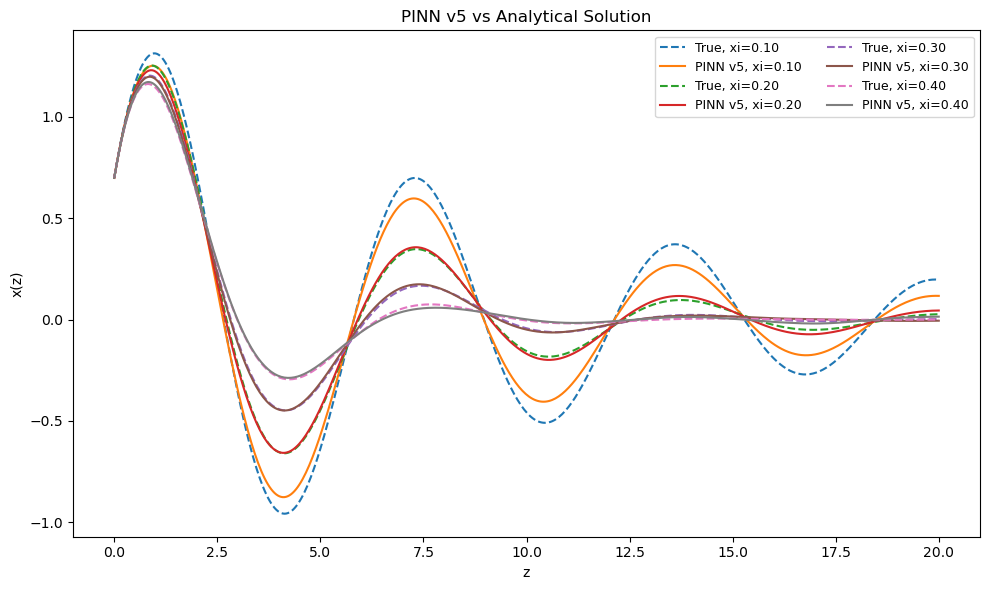

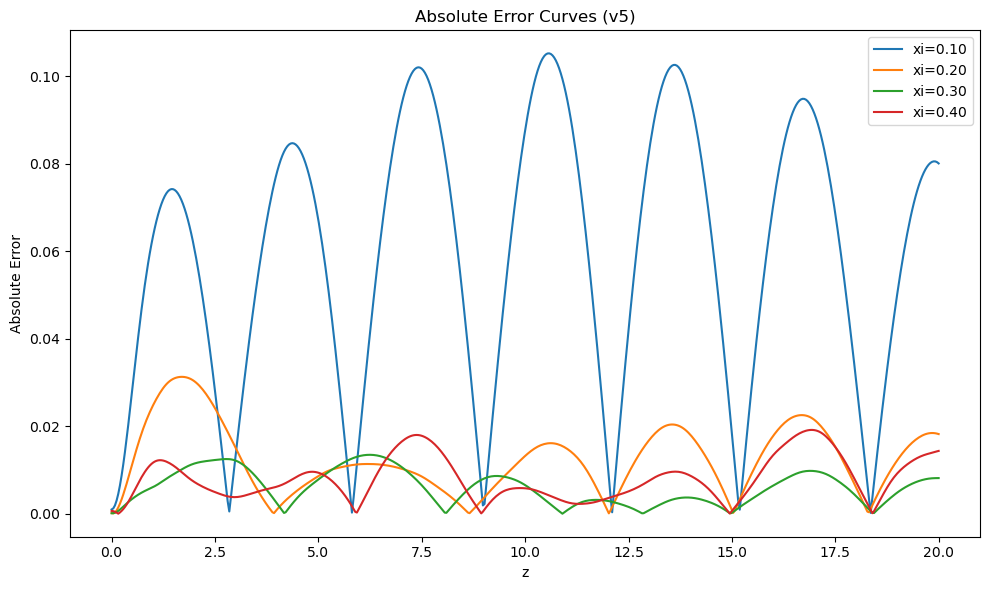

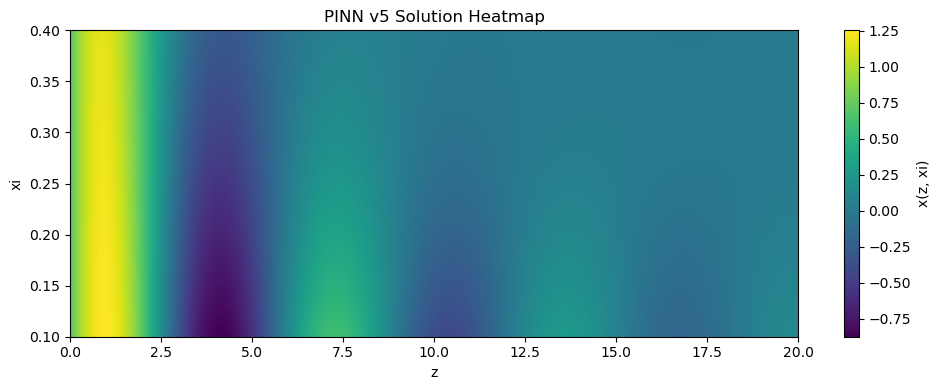


Model saved to pinnde_v5_model.pt


In [19]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X0 = 0.7
V0 = 1.2

XI_MIN = 0.1
XI_MAX = 0.4

Z_MIN = 0.0
Z_MAX = 20.0


def analytical_solution(z, xi, x0=X0, v0=V0):
    z_np = np.asarray(z, dtype=np.float64)
    xi_np = np.asarray(xi, dtype=np.float64)

    wd = np.sqrt(1.0 - xi_np**2)
    c1 = x0
    c2 = (v0 + xi_np * x0) / wd

    return np.exp(-xi_np * z_np) * (
        c1 * np.cos(wd * z_np) + c2 * np.sin(wd * z_np)
    )


def normalize_z(z):
    return 2.0 * z / Z_MAX - 1.0


def normalize_xi(xi):
    return 2.0 * (xi - XI_MIN) / (XI_MAX - XI_MIN) - 1.0


class FourierFeatures(nn.Module):
    def __init__(self, num_bands=4):
        super().__init__()
        self.num_bands = num_bands
        self.freqs = 2.0 ** torch.arange(num_bands, dtype=torch.float32)

    def forward(self, z_norm, xi_norm):
        freqs = self.freqs.to(z_norm.device).view(1, -1)
        z_proj = math.pi * z_norm * freqs
        sin_z = torch.sin(z_proj)
        cos_z = torch.cos(z_proj)

        return torch.cat(
            [z_norm, xi_norm, sin_z, cos_z, z_norm * xi_norm],
            dim=1
        )


class PINNv5(nn.Module):
    def __init__(self, hidden_dim=128, num_hidden=4, num_bands=4):
        super().__init__()
        self.encoder = FourierFeatures(num_bands=num_bands)
        in_dim = 2 + 2 * num_bands + 1

        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 1)]

        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, z, xi):
        z_norm = normalize_z(z)
        xi_norm = normalize_xi(xi)
        feat = self.encoder(z_norm, xi_norm)
        return self.net(feat)


def sample_initial(n_samples):
    z0 = torch.zeros(n_samples, 1, device=device)
    xi = torch.rand(n_samples, 1, device=device) * (XI_MAX - XI_MIN) + XI_MIN
    z0.requires_grad_(True)
    return z0, xi


def sample_interior_biased(n_samples, z_upper):
    u = torch.rand(n_samples, 1, device=device)
    z = z_upper * torch.sqrt(u)

    u2 = torch.rand(n_samples, 1, device=device)
    xi = XI_MIN + (XI_MAX - XI_MIN) * (u2 ** 1.5)

    z.requires_grad_(True)
    return z, xi


def compute_residual(model, z, xi):
    x = model(z, xi)

    dx_dz = torch.autograd.grad(
        x, z,
        grad_outputs=torch.ones_like(x),
        create_graph=True,
        retain_graph=True
    )[0]

    d2x_dz2 = torch.autograd.grad(
        dx_dz, z,
        grad_outputs=torch.ones_like(dx_dz),
        create_graph=True,
        retain_graph=True
    )[0]

    residual = d2x_dz2 + 2.0 * xi * dx_dz + x
    return x, dx_dz, d2x_dz2, residual


def loss_fn(model, n_interior=1024, n_initial=256, z_upper=20.0, lambda_ic=20.0):
    z_r, xi_r = sample_interior_biased(n_interior, z_upper)
    _, _, _, residual = compute_residual(model, z_r, xi_r)
    loss_phys = torch.mean(residual ** 2)

    z0, xi0 = sample_initial(n_initial)
    x0_pred = model(z0, xi0)

    dx0_dz = torch.autograd.grad(
        x0_pred, z0,
        grad_outputs=torch.ones_like(x0_pred),
        create_graph=True,
        retain_graph=True
    )[0]

    loss_x0 = torch.mean((x0_pred - X0) ** 2)
    loss_v0 = torch.mean((dx0_dz - V0) ** 2)
    loss_ic = loss_x0 + loss_v0

    loss = loss_phys + lambda_ic * loss_ic
    return loss, loss_phys.detach(), loss_ic.detach()


def train_curriculum(model, curriculum_stages):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

    history = {"loss": [], "phys": [], "ic": []}
    model.train()

    global_epoch = 0
    for stage_id, stage in enumerate(curriculum_stages, start=1):
        z_upper = stage["z_upper"]
        epochs = stage["epochs"]
        lambda_ic = stage.get("lambda_ic", 20.0)
        n_interior = stage.get("n_interior", 1024)
        n_initial = stage.get("n_initial", 256)

        print(f"\n=== Stage {stage_id}: train on z in [0, {z_upper}] for {epochs} epochs ===")

        for epoch in range(1, epochs + 1):
            global_epoch += 1
            optimizer.zero_grad()

            loss, loss_phys, loss_ic = loss_fn(
                model,
                n_interior=n_interior,
                n_initial=n_initial,
                z_upper=z_upper,
                lambda_ic=lambda_ic
            )

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Numerical issue at global epoch {global_epoch}, stopping.")
                return history

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            history["loss"].append(loss.item())
            history["phys"].append(loss_phys.item())
            history["ic"].append(loss_ic.item())

            if global_epoch % 500 == 0 or epoch == 1:
                print(
                    f"Global Epoch {global_epoch:5d} | "
                    f"Total: {loss.item():.6e} | "
                    f"Phys: {loss_phys.item():.6e} | "
                    f"IC: {loss_ic.item():.6e}"
                )

    return history


def build_residual_pool(model, num_z=200, num_xi=80):
    """
    Build a pool of candidate points and compute residual magnitude.
    """
    z_vals = torch.linspace(Z_MIN, Z_MAX, num_z, device=device).view(-1, 1)
    xi_vals = torch.linspace(XI_MIN, XI_MAX, num_xi, device=device).view(-1, 1)

    ZZ, XX = torch.meshgrid(z_vals.squeeze(), xi_vals.squeeze(), indexing="ij")
    z_pool = ZZ.reshape(-1, 1).clone().detach().requires_grad_(True)
    xi_pool = XX.reshape(-1, 1).clone().detach()

    _, _, _, residual = compute_residual(model, z_pool, xi_pool)
    res_abs = residual.detach().abs().reshape(-1)

    return z_pool.detach(), xi_pool.detach(), res_abs


def sample_interior_adaptive(model, n_samples, mix_ratio=0.7):
    """
    mix:
    - part from residual-based adaptive pool
    - part from biased random sampling
    """
    n_adapt = int(n_samples * mix_ratio)
    n_rand = n_samples - n_adapt

    z_pool, xi_pool, res_abs = build_residual_pool(model)

    weights = res_abs + 1e-8
    weights = weights / weights.sum()

    idx = torch.multinomial(weights, n_adapt, replacement=True)
    z_adapt = z_pool[idx].clone().detach()
    xi_adapt = xi_pool[idx].clone().detach()

    z_rand, xi_rand = sample_interior_biased(n_rand, Z_MAX)
    z_rand = z_rand.detach()
    xi_rand = xi_rand.detach()

    z = torch.cat([z_adapt, z_rand], dim=0).requires_grad_(True)
    xi = torch.cat([xi_adapt, xi_rand], dim=0)

    return z, xi


def adaptive_loss_fn(model, n_interior=2048, n_initial=256, lambda_ic=15.0):
    z_r, xi_r = sample_interior_adaptive(model, n_interior, mix_ratio=0.7)
    _, _, _, residual = compute_residual(model, z_r, xi_r)
    loss_phys = torch.mean(residual ** 2)

    z0, xi0 = sample_initial(n_initial)
    x0_pred = model(z0, xi0)
    dx0_dz = torch.autograd.grad(
        x0_pred, z0,
        grad_outputs=torch.ones_like(x0_pred),
        create_graph=True,
        retain_graph=True
    )[0]

    loss_x0 = torch.mean((x0_pred - X0) ** 2)
    loss_v0 = torch.mean((dx0_dz - V0) ** 2)
    loss_ic = loss_x0 + loss_v0

    loss = loss_phys + lambda_ic * loss_ic
    return loss, loss_phys.detach(), loss_ic.detach()


def fine_tune_adaptive(model, epochs=2000, lr=3e-4, n_interior=2048, n_initial=256):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "phys": [], "ic": []}

    model.train()
    print("\n=== Adaptive fine-tuning ===")
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        loss, loss_phys, loss_ic = adaptive_loss_fn(
            model,
            n_interior=n_interior,
            n_initial=n_initial,
            lambda_ic=15.0
        )

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Numerical issue in adaptive fine-tune at epoch {epoch}, stopping.")
            return history

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        history["loss"].append(loss.item())
        history["phys"].append(loss_phys.item())
        history["ic"].append(loss_ic.item())

        if epoch % 250 == 0 or epoch == 1:
            print(
                f"[Adaptive] Epoch {epoch:5d} | "
                f"Total: {loss.item():.6e} | "
                f"Phys: {loss_phys.item():.6e} | "
                f"IC: {loss_ic.item():.6e}"
            )

    return history


def train_lbfgs_safe(model, max_iter=150, n_interior=4096, n_initial=512, lambda_ic=15.0):
    """
    Optional final polishing.
    """
    print("\n=== Safe L-BFGS polishing ===")
    model.train()

    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=0.3,
        max_iter=max_iter,
        max_eval=max_iter,
        tolerance_grad=1e-9,
        tolerance_change=1e-12,
        history_size=50,
        line_search_fn="strong_wolfe",
    )

    z_r, xi_r = sample_interior_biased(n_interior, Z_MAX)
    z_r = z_r.detach().clone().requires_grad_(True)
    xi_r = xi_r.detach().clone()

    z0, xi0 = sample_initial(n_initial)

    history = {"loss": []}

    def closure():
        optimizer.zero_grad()

        _, _, _, residual = compute_residual(model, z_r, xi_r)
        loss_phys = torch.mean(residual ** 2)

        x0_pred = model(z0, xi0)
        dx0_dz = torch.autograd.grad(
            x0_pred, z0,
            grad_outputs=torch.ones_like(x0_pred),
            create_graph=True,
            retain_graph=True
        )[0]

        loss_x0 = torch.mean((x0_pred - X0) ** 2)
        loss_v0 = torch.mean((dx0_dz - V0) ** 2)
        loss_ic = loss_x0 + loss_v0

        loss = loss_phys + lambda_ic * loss_ic

        if torch.isnan(loss) or torch.isinf(loss):
            raise RuntimeError("NaN/Inf encountered in L-BFGS closure.")

        loss.backward()
        history["loss"].append(loss.item())
        return loss

    try:
        final_loss = optimizer.step(closure)
        print(f"[L-BFGS] Final loss: {final_loss.item():.6e}")
    except Exception as e:
        print(f"L-BFGS stopped due to: {e}")

    return history


@torch.no_grad()
def predict(model, z, xi):
    z_t = torch.tensor(z, dtype=torch.float32, device=device).reshape(-1, 1)
    xi_t = torch.full_like(z_t, fill_value=float(xi))
    pred = model(z_t, xi_t).cpu().numpy().reshape(-1)
    return pred


def evaluate_error(model, xi_values, num_points=500):
    results = []
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    for xi in xi_values:
        y_pred = predict(model, z, xi)
        y_true = analytical_solution(z, xi)

        abs_err = np.abs(y_pred - y_true)
        l2_err = np.sqrt(np.mean((y_pred - y_true) ** 2))
        max_err = np.max(abs_err)

        results.append({
            "xi": xi,
            "l2_error": float(l2_err),
            "max_error": float(max_err),
        })

    return results


def check_initial_conditions(model, xi_values):
    print("\nInitial-condition check:")
    for xi in xi_values:
        z0 = torch.tensor([[0.0]], dtype=torch.float32, device=device, requires_grad=True)
        xi_t = torch.tensor([[xi]], dtype=torch.float32, device=device)

        x0_pred = model(z0, xi_t)
        dx0 = torch.autograd.grad(
            x0_pred, z0,
            grad_outputs=torch.ones_like(x0_pred),
            create_graph=False,
            retain_graph=False
        )[0]

        print(
            f"xi={xi:.2f} | "
            f"x(0) pred={x0_pred.item():.8f} | "
            f"x'(0) pred={dx0.item():.8f}"
        )


def plot_training_history(history, title="Training Loss"):
    plt.figure(figsize=(8, 5))
    if "loss" in history:
        plt.semilogy(history["loss"], label="Total loss")
    if "phys" in history:
        plt.semilogy(history["phys"], label="Physics loss")
    if "ic" in history:
        plt.semilogy(history["ic"], label="IC loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss (log scale)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_predictions(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)

        plt.plot(z, y_true, linestyle="--", label=f"True, xi={xi:.2f}")
        plt.plot(z, y_pred, label=f"PINN v5, xi={xi:.2f}")

    plt.xlabel("z")
    plt.ylabel("x(z)")
    plt.title("PINN v5 vs Analytical Solution")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_error_curves(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)

    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)
        abs_err = np.abs(y_pred - y_true)
        plt.plot(z, abs_err, label=f"xi={xi:.2f}")

    plt.xlabel("z")
    plt.ylabel("Absolute Error")
    plt.title("Absolute Error Curves (v5)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_solution_heatmap(model, num_z=300, num_xi=100):
    z_grid = np.linspace(Z_MIN, Z_MAX, num_z)
    xi_grid = np.linspace(XI_MIN, XI_MAX, num_xi)

    Z, XI = np.meshgrid(z_grid, xi_grid)
    z_t = torch.tensor(Z.reshape(-1, 1), dtype=torch.float32, device=device)
    xi_t = torch.tensor(XI.reshape(-1, 1), dtype=torch.float32, device=device)

    with torch.no_grad():
        pred = model(z_t, xi_t).cpu().numpy().reshape(num_xi, num_z)

    plt.figure(figsize=(10, 4))
    plt.imshow(
        pred,
        aspect="auto",
        origin="lower",
        extent=[Z_MIN, Z_MAX, XI_MIN, XI_MAX],
    )
    plt.colorbar(label="x(z, xi)")
    plt.xlabel("z")
    plt.ylabel("xi")
    plt.title("PINN v5 Solution Heatmap")
    plt.tight_layout()
    plt.show()


def main():
    model = PINNv5(hidden_dim=128, num_hidden=4, num_bands=4).to(device)

    curriculum_stages = [
        {"z_upper": 5.0,  "epochs": 2000, "lambda_ic": 30.0, "n_interior": 1024, "n_initial": 256},
        {"z_upper": 10.0, "epochs": 2000, "lambda_ic": 20.0, "n_interior": 1024, "n_initial": 256},
        {"z_upper": 15.0, "epochs": 2000, "lambda_ic": 20.0, "n_interior": 1536, "n_initial": 256},
        {"z_upper": 20.0, "epochs": 3000, "lambda_ic": 15.0, "n_interior": 2048, "n_initial": 256},
    ]

    history_main = train_curriculum(model, curriculum_stages)
    plot_training_history(history_main, title="Training Loss (v5 curriculum)")

    history_adapt = fine_tune_adaptive(
        model,
        epochs=1500,
        lr=3e-4,
        n_interior=2048,
        n_initial=256
    )
    plot_training_history(history_adapt, title="Adaptive Fine-Tuning Loss (v5)")

    # optional
    history_lbfgs = train_lbfgs_safe(
        model,
        max_iter=100,
        n_interior=4096,
        n_initial=512,
        lambda_ic=15.0
    )

    xi_values = [0.1, 0.2, 0.3, 0.4]

    check_initial_conditions(model, xi_values)
    results = evaluate_error(model, xi_values)

    print("\nError Summary:")
    for r in results:
        print(
            f"xi={r['xi']:.2f} | "
            f"L2 error={r['l2_error']:.6e} | "
            f"Max error={r['max_error']:.6e}"
        )

    plot_predictions(model, xi_values)
    plot_error_curves(model, xi_values)
    plot_solution_heatmap(model)

    torch.save(model.state_dict(), "pinnde_v5_model.pt")
    print("\nModel saved to pinnde_v5_model.pt")


if __name__ == "__main__":
    main()

# v6

In [21]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X0 = 0.7
V0 = 1.2
XI_MIN = 0.1
XI_MAX = 0.4
Z_MIN = 0.0
Z_MAX = 20.0


def analytical_solution(z, xi, x0=X0, v0=V0):
    z_np = np.asarray(z, dtype=np.float64)
    xi_np = np.asarray(xi, dtype=np.float64)
    wd = np.sqrt(1.0 - xi_np**2)
    c1 = x0
    c2 = (v0 + xi_np * x0) / wd
    return np.exp(-xi_np * z_np) * (
        c1 * np.cos(wd * z_np) + c2 * np.sin(wd * z_np)
    )


def normalize_z(z):
    return 2.0 * z / Z_MAX - 1.0


def normalize_xi(xi):
    return 2.0 * (xi - XI_MIN) / (XI_MAX - XI_MIN) - 1.0


class FourierFeatures(nn.Module):
    def __init__(self, num_bands=4):
        super().__init__()
        self.freqs = 2.0 ** torch.arange(num_bands, dtype=torch.float32)

    def forward(self, z_norm, xi_norm):
        freqs = self.freqs.to(z_norm.device).view(1, -1)
        z_proj = math.pi * z_norm * freqs
        return torch.cat(
            [z_norm, xi_norm, torch.sin(z_proj), torch.cos(z_proj), z_norm * xi_norm],
            dim=1
        )


class PINN(nn.Module):
    def __init__(self, hidden_dim=128, num_hidden=4, num_bands=4):
        super().__init__()
        self.encoder = FourierFeatures(num_bands=num_bands)
        in_dim = 2 + 2 * num_bands + 1

        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 1)]
        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, z, xi):
        z_norm = normalize_z(z)
        xi_norm = normalize_xi(xi)
        feat = self.encoder(z_norm, xi_norm)
        return self.net(feat)


def sample_initial(n_samples):
    z0 = torch.zeros(n_samples, 1, device=device)
    xi = torch.rand(n_samples, 1, device=device) * (XI_MAX - XI_MIN) + XI_MIN
    z0.requires_grad_(True)
    return z0, xi


def sample_interior_biased(n_samples, z_upper):
    u = torch.rand(n_samples, 1, device=device)
    z = z_upper * torch.sqrt(u)

    u2 = torch.rand(n_samples, 1, device=device)
    xi = XI_MIN + (XI_MAX - XI_MIN) * (u2 ** 1.5)

    z.requires_grad_(True)
    return z, xi


def sample_interior_hardcase(n_samples):
    """
    Focus on hardest region:
    xi in [0.10, 0.16], z in [8, 20]
    """
    z = 8.0 + 12.0 * torch.rand(n_samples, 1, device=device)
    xi = 0.10 + 0.06 * torch.rand(n_samples, 1, device=device)
    z.requires_grad_(True)
    return z, xi


def compute_residual(model, z, xi):
    x = model(z, xi)

    dx_dz = torch.autograd.grad(
        x, z,
        grad_outputs=torch.ones_like(x),
        create_graph=True,
        retain_graph=True
    )[0]

    d2x_dz2 = torch.autograd.grad(
        dx_dz, z,
        grad_outputs=torch.ones_like(dx_dz),
        create_graph=True,
        retain_graph=True
    )[0]

    residual = d2x_dz2 + 2.0 * xi * dx_dz + x
    return x, dx_dz, d2x_dz2, residual


def build_residual_pool(model, num_z=200, num_xi=80):
    z_vals = torch.linspace(Z_MIN, Z_MAX, num_z, device=device).view(-1, 1)
    xi_vals = torch.linspace(XI_MIN, XI_MAX, num_xi, device=device).view(-1, 1)

    ZZ, XX = torch.meshgrid(z_vals.squeeze(), xi_vals.squeeze(), indexing="ij")
    z_pool = ZZ.reshape(-1, 1).clone().detach().requires_grad_(True)
    xi_pool = XX.reshape(-1, 1).clone().detach()

    _, _, _, residual = compute_residual(model, z_pool, xi_pool)
    res_abs = residual.detach().abs().reshape(-1)

    return z_pool.detach(), xi_pool.detach(), res_abs


def sample_interior_adaptive(model, n_samples, mix_ratio=0.5, hard_ratio=0.25):
    """
    mix of:
    - residual adaptive
    - hard-case focused
    - biased random
    """
    n_adapt = int(n_samples * mix_ratio)
    n_hard = int(n_samples * hard_ratio)
    n_rand = n_samples - n_adapt - n_hard

    z_pool, xi_pool, res_abs = build_residual_pool(model)
    weights = res_abs + 1e-8
    weights = weights / weights.sum()

    idx = torch.multinomial(weights, n_adapt, replacement=True)
    z_adapt = z_pool[idx].clone().detach()
    xi_adapt = xi_pool[idx].clone().detach()

    z_hard, xi_hard = sample_interior_hardcase(n_hard)
    z_hard = z_hard.detach()
    xi_hard = xi_hard.detach()

    z_rand, xi_rand = sample_interior_biased(n_rand, Z_MAX)
    z_rand = z_rand.detach()
    xi_rand = xi_rand.detach()

    z = torch.cat([z_adapt, z_hard, z_rand], dim=0).requires_grad_(True)
    xi = torch.cat([xi_adapt, xi_hard, xi_rand], dim=0)
    return z, xi


def hardcase_loss_fn(model, n_interior=2048, n_initial=256, lambda_ic=15.0):
    z_r, xi_r = sample_interior_adaptive(model, n_interior, mix_ratio=0.5, hard_ratio=0.3)
    _, _, _, residual = compute_residual(model, z_r, xi_r)
    loss_phys = torch.mean(residual ** 2)

    z0, xi0 = sample_initial(n_initial)
    x0_pred = model(z0, xi0)
    dx0_dz = torch.autograd.grad(
        x0_pred, z0,
        grad_outputs=torch.ones_like(x0_pred),
        create_graph=True,
        retain_graph=True
    )[0]

    loss_x0 = torch.mean((x0_pred - X0) ** 2)
    loss_v0 = torch.mean((dx0_dz - V0) ** 2)
    loss_ic = loss_x0 + loss_v0

    loss = loss_phys + lambda_ic * loss_ic
    return loss, loss_phys.detach(), loss_ic.detach()


def fine_tune_hardcase(model, epochs=1200, lr=1e-4, n_interior=2048, n_initial=256):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "phys": [], "ic": []}

    print("\n=== Hard-case fine-tuning (v6) ===")
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        loss, loss_phys, loss_ic = hardcase_loss_fn(
            model,
            n_interior=n_interior,
            n_initial=n_initial,
            lambda_ic=15.0
        )

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Numerical issue in hard-case fine-tune at epoch {epoch}, stopping.")
            return history

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        history["loss"].append(loss.item())
        history["phys"].append(loss_phys.item())
        history["ic"].append(loss_ic.item())

        if epoch % 200 == 0 or epoch == 1:
            print(
                f"[HardCase] Epoch {epoch:5d} | "
                f"Total: {loss.item():.6e} | "
                f"Phys: {loss_phys.item():.6e} | "
                f"IC: {loss_ic.item():.6e}"
            )

    return history


@torch.no_grad()
def predict(model, z, xi):
    z_t = torch.tensor(z, dtype=torch.float32, device=device).reshape(-1, 1)
    xi_t = torch.full_like(z_t, fill_value=float(xi))
    return model(z_t, xi_t).cpu().numpy().reshape(-1)


def evaluate_error(model, xi_values, num_points=500):
    results = []
    z = np.linspace(Z_MIN, Z_MAX, num_points)
    for xi in xi_values:
        y_pred = predict(model, z, xi)
        y_true = analytical_solution(z, xi)
        abs_err = np.abs(y_pred - y_true)
        l2_err = np.sqrt(np.mean((y_pred - y_true) ** 2))
        max_err = np.max(abs_err)
        results.append((xi, l2_err, max_err))
    return results


def plot_training_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.semilogy(history["loss"], label="Total loss")
    plt.semilogy(history["phys"], label="Physics loss")
    plt.semilogy(history["ic"], label="IC loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss (log scale)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_predictions(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)
    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)
        plt.plot(z, y_true, "--", label=f"True, xi={xi:.2f}")
        plt.plot(z, y_pred, label=f"PINN v6, xi={xi:.2f}")
    plt.xlabel("z")
    plt.ylabel("x(z)")
    plt.title("PINN v6 vs Analytical Solution")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_error_curves(model, xi_values, num_points=500):
    z = np.linspace(Z_MIN, Z_MAX, num_points)
    plt.figure(figsize=(10, 6))
    for xi in xi_values:
        y_true = analytical_solution(z, xi)
        y_pred = predict(model, z, xi)
        plt.plot(z, np.abs(y_pred - y_true), label=f"xi={xi:.2f}")
    plt.xlabel("z")
    plt.ylabel("Absolute Error")
    plt.title("Absolute Error Curves (v6)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Using device: cpu



=== Hard-case fine-tuning (v6) ===
[HardCase] Epoch     1 | Total: 2.944311e-03 | Phys: 2.943276e-03 | IC: 6.903361e-08
[HardCase] Epoch   200 | Total: 8.503954e-05 | Phys: 8.159089e-05 | IC: 2.299103e-07
[HardCase] Epoch   400 | Total: 7.777855e-05 | Phys: 7.377293e-05 | IC: 2.670411e-07
[HardCase] Epoch   600 | Total: 8.241153e-05 | Phys: 6.776739e-05 | IC: 9.762757e-07
[HardCase] Epoch   800 | Total: 9.042806e-05 | Phys: 6.646227e-05 | IC: 1.597720e-06
[HardCase] Epoch  1000 | Total: 9.297233e-05 | Phys: 5.922014e-05 | IC: 2.250146e-06
[HardCase] Epoch  1200 | Total: 7.086235e-05 | Phys: 5.640247e-05 | IC: 9.639919e-07


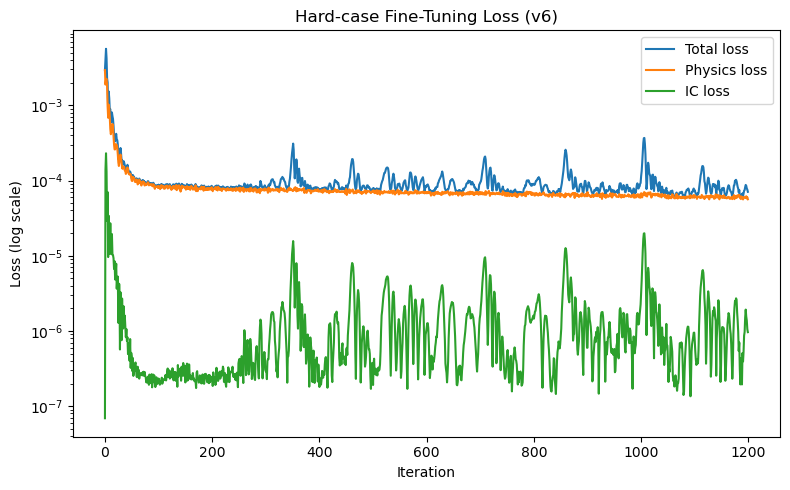

xi=0.10 | L2 error=4.726235e-02 | Max error=8.038976e-02
xi=0.20 | L2 error=1.355944e-02 | Max error=2.446664e-02
xi=0.30 | L2 error=4.940703e-03 | Max error=1.058684e-02
xi=0.40 | L2 error=7.513273e-03 | Max error=1.654397e-02


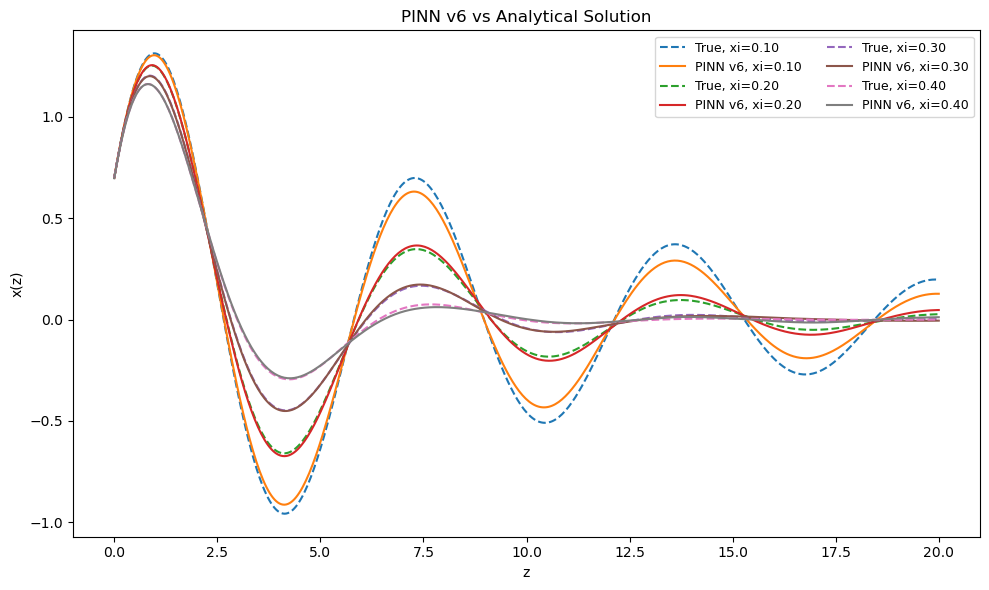

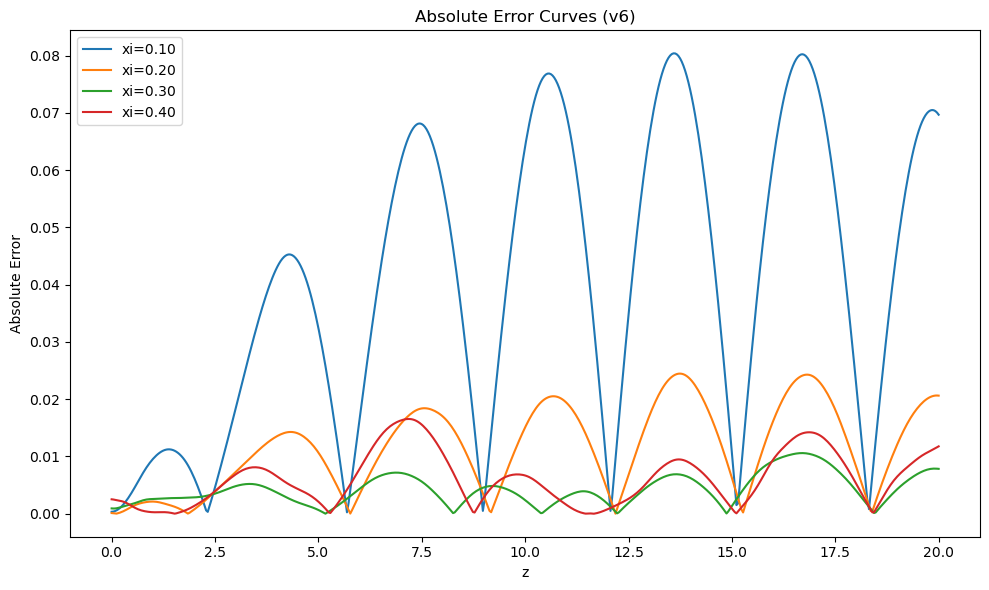

In [22]:
model = PINN(hidden_dim=128, num_hidden=4, num_bands=4).to(device)
model.load_state_dict(torch.load("pinnde_v5_model.pt", map_location=device))

history_hard = fine_tune_hardcase(
    model,
    epochs=1200,
    lr=1e-4,
    n_interior=2048,
    n_initial=256
)

plot_training_history(history_hard, title="Hard-case Fine-Tuning Loss (v6)")

xi_values = [0.1, 0.2, 0.3, 0.4]
results = evaluate_error(model, xi_values)
for xi, l2_err, max_err in results:
    print(f"xi={xi:.2f} | L2 error={l2_err:.6e} | Max error={max_err:.6e}")

plot_predictions(model, xi_values)
plot_error_curves(model, xi_values)

torch.save(model.state_dict(), "pinnde_v6_model.pt")